# Colab reward shaping run v1

本 notebook 用于直接运行改进版实验。

主线保持不变：
- BenchMARL + VMAS
- MAPPO baseline
- reward shaping v1

实现方式：
- 通过 `src/run_reward_shaping_v1.py` 先 patch `VMAS/navigation` 的 reward
- 再在同一进程中调用 `benchmarl.run` 启动训练


## 1. Clone repo

In [2]:
!git clone https://github.com/WonderfulClaire/low_altitude_marl.git
%cd /content/low_altitude_marl
!ls src

Cloning into 'low_altitude_marl'...
remote: Enumerating objects: 215, done.
remote: Counting objects: 100% (28/28), done.
remote: Compressing objects: 100% (27/27), done.
remote: Total 215 (delta 9), reused 0 (delta 0), pack-reused 187 (from 1)
Receiving objects: 100% (215/215), 299.92 KiB | 24.99 MiB/s, done.
Resolving deltas: 100% (100/100), done.
/content/low_altitude_marl
analyze_logs.py      notes.md		       scenario_mapping.md
compare_two_runs.py  reward_shaping_design.md
metrics_summary.py   run_reward_shaping_v1.py


## 2. Install dependencies

In [3]:
%cd /content/low_altitude_marl
!python -m pip install --upgrade pip
!python -m pip install -r requirements.txt

/content/low_altitude_marl
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 69.1 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 89.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 75.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.4/34.4 MB 126.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 83.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 209.3 MB/s  0:00:00
  Created wheel for vmas: filename=vmas-1.5.2-py3-none-any.whl size=260328 sha256=9e259ceed1b07896df23e0ad6

In [4]:
import re
from pathlib import Path

def extract_metrics_from_log(log_path):
    text = Path(log_path).read_text(errors="ignore")

    patterns = {
        "Reward": r"collection/reward/episode_reward_mean\s+([-+]?\d*\.\d+|[-+]?\d+)",
        "Pos_Rew": r"collection/agents/info/pos_rew\s+([-+]?\d*\.\d+|[-+]?\d+)",
        "Agent_Collisions": r"collection/agents/info/agent_collisions\s+([-+]?\d*\.\d+|[-+]?\d+)",
        "Final_Rew": r"collection/agents/info/final_rew\s+([-+]?\d*\.\d+|[-+]?\d+)",
    }

    result = {}
    for key, pat in patterns.items():
        matches = re.findall(pat, text)
        result[key] = float(matches[-1]) if matches else None

    if result["Agent_Collisions"] is not None:
        result["Collision_Risk"] = abs(result["Agent_Collisions"])
    else:
        result["Collision_Risk"] = None

    print("===== Extracted Metrics =====")
    print(f"log_path        : {log_path}")
    print(f"Reward          : {result['Reward']}")
    print(f"Pos_Rew         : {result['Pos_Rew']}")
    print(f"Agent_Collisions: {result['Agent_Collisions']}")
    print(f"Collision_Risk  : {result['Collision_Risk']}")
    print(f"Final_Rew       : {result['Final_Rew']}")
    print("=============================")

    return result

## 3. Read reward design

In [ ]:
%cd /content/low_altitude_marl
!sed -n '1,220p' src/reward_shaping_design.md
print('\n' + '='*80 + '\n')
!sed -n '1,240p' src/run_reward_shaping_v1.py

/content/low_altitude_marl
# Reward Shaping v1

## Objective
在 VMAS/navigation 的 MAPPO baseline 上，引入更贴近低空多无人机协同飞行任务的奖励设计，以提升策略在安全性、效率与轨迹质量方面的表现。

## Reward terms
### 1. Goal reward
- 无人机成功到达目标点时给予较大正奖励。
- 用于突出任务完成的重要性。

### 2. Progress reward
- 若当前时间步相比上一步更接近目标点，则给予小幅正奖励。
- 用于缓解稀疏奖励问题，加速训练收敛。

### 3. Collision penalty
- 与障碍物或其他 agent 发生碰撞时给予较大负奖励。
- 用于强调飞行安全约束。

### 4. Risk penalty
- 当无人机距离障碍物过近时给予额外惩罚。
- 用于模拟低空场景中的高风险区域、建筑边界和禁飞区邻近效应。

### 5. Smoothness penalty
- 当连续两个时间步动作变化过大时给予惩罚。
- 用于鼓励更平滑的轨迹，减少抖动与急转弯。

## Proposed formulation
可以将总奖励写成：

R = w1 * R_goal + w2 * R_progress - w3 * R_collision - w4 * R_risk - w5 * R_smooth

其中各权重后续通过实验进行调节。

## Low-altitude scenario mapping
- obstacle -> 建筑物 / 禁飞区 / 高风险区域
- goal -> 配送点 / 巡检点 / 任务点
- collision -> 空域冲突 / 飞行安全风险
- path smoothness -> 飞行稳定性与控制友好性
- progress -> 任务推进效率

## Current plan
1. 先保留原始 MAPPO baseline 作为对照组。
2. 在不推翻现有训练平台的前提下，逐步将 reward shaping 引入任务。
3. 后续通过 episode_reward_mean、reward_mean、collision 相关指标和轨迹可视化比较改进前后的效果。


from __futur

## 4. Check torch and GPU

In [4]:
import torch
print('torch version:', torch.__version__)
print('cuda available:', torch.cuda.is_available())
print('gpu count:', torch.cuda.device_count())
if torch.cuda.is_available():
    print('gpu name:', torch.cuda.get_device_name(0))

torch version: 2.10.0+cu128
cuda available: True
gpu count: 1
gpu name: NVIDIA L4


## 4. Patch navigation reward (source-level)

In [ ]:
import pathlib, textwrap

nav_path = pathlib.Path("/usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py")
src = nav_path.read_text(encoding="utf-8")

if "# [rs_patch]" in src:
    src = src[:src.index("# [rs_patch]")]
    print("旧 patch 已清除")

patch = textwrap.dedent("""
    # [rs_patch]
    import torch as _torch
    _rs_orig_reward = Scenario.reward
    _rs_orig_reset  = Scenario.reset_world_at

    def _rs_reset(self, env_index=None):
      out = _rs_orig_reset(self, env_index)
      if not hasattr(self, "_rs_pd"):
        self._rs_pd = {}
        self._rs_pa = {}

      if env_index is None:
        self._rs_pd.clear()
        self._rs_pa.clear()
      else:
        for d in (self._rs_pd, self._rs_pa):
            for k, v in list(d.items()):
                if isinstance(v, _torch.Tensor) and v.ndim > 0 and env_index < v.shape[0]:
                    v = v.clone()
                    v[env_index] = _torch.nan
                    d[k] = v
      return out

    def _rs_reward(self, agent):
      base = _rs_orig_reward(self, agent)
      if not isinstance(base, _torch.Tensor):
        return base

      r = base.clone()
      zero = _torch.zeros_like(r)

      if not hasattr(self, "_rs_pd"):
        self._rs_pd = {}
        self._rs_pa = {}

      key = getattr(agent, "name", str(id(agent)))
      ap = getattr(getattr(agent, "state", None), "pos", None)
      gp = getattr(getattr(getattr(agent, "goal", None), "state", None), "pos", None)
      dist = _torch.linalg.vector_norm(ap - gp, dim=-1) if (ap is not None and gp is not None) else None

    # progress reward
      prog = zero
      if dist is not None:
        pd = self._rs_pd.get(key)
        if pd is not None and pd.shape == dist.shape:
            valid = _torch.isfinite(pd)
            prog = _torch.where(valid, 0.05 * (pd - dist), zero)
        self._rs_pd[key] = dist.detach().clone()

    # smoothness penalty
      smooth = zero
      act = getattr(getattr(agent, "action", None), "u", None)
      if act is not None:
        pa = self._rs_pa.get(key)
        if pa is not None and pa.shape == act.shape:
            diff = _torch.linalg.vector_norm(act - pa, dim=-1)
            valid = _torch.isfinite(pa).all(dim=-1) if pa.ndim > 1 else _torch.isfinite(pa).all()
            smooth = _torch.where(valid, 0.002 * diff, zero)
        self._rs_pa[key] = act.detach().clone()

    # risk penalty
      risk = zero
      world = getattr(self, "world", None)
      landmarks = getattr(world, "landmarks", []) if world else []
      mc = None

      ar = 0.0
      try:
        ar = float(getattr(getattr(agent, "shape", None), "radius", 0.0))
      except Exception:
        pass

      for lm in landmarks:
        if lm is getattr(agent, "goal", None):
            continue
        lp = getattr(getattr(lm, "state", None), "pos", None)
        if lp is None or ap is None:
            continue
        lr = 0.0
        try:
            lr = float(getattr(getattr(lm, "shape", None), "radius", 0.0))
        except Exception:
            pass
        cl = _torch.linalg.vector_norm(ap - lp, dim=-1) - ar - lr
        mc = cl if mc is None else _torch.minimum(mc, cl)

      if mc is not None:
        thr = _torch.as_tensor(0.05, dtype=mc.dtype, device=mc.device)
        risk_raw = _torch.relu(thr - mc) / thr
        risk = _torch.clamp(0.03 * risk_raw, max=0.03)

      return r + prog - smooth - risk

    Scenario.reward         = _rs_reward
    Scenario.reset_world_at = _rs_reset
    print("[rs_patch] reward shaping patch applied")
""")

src += "\n" + patch
nav_path.write_text(src, encoding="utf-8")

pyc = pathlib.Path("/usr/local/lib/python3.12/dist-packages/vmas/scenarios/__pycache__/navigation.cpython-312.pyc")
if pyc.exists():
    pyc.unlink()

print("patch 写入完成:", nav_path)

旧 patch 已清除
patch 写入完成: /usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py


## 5. Run reward shaping v1 (short run)

In [ ]:
%cd /content/low_altitude_marl
import os
os.environ['WANDB_MODE'] = 'disabled'

!python -m benchmarl.run \
  algorithm=mappo \
  task=vmas/navigation \
  experiment.render=false \
  experiment.evaluation=false \
  experiment.max_n_frames=300000 \
  seed=0

/content/low_altitude_marl

Algorithm: mappo, Task: vmas/navigation

Loaded config:

experiment:
  sampling_device: cpu
  train_device: cpu
  buffer_device: cpu
  share_policy_params: true
  prefer_continuous_actions: true
  collect_with_grad: false
  parallel_collection: false
  gamma: 0.99
  lr: 5.0e-05
  adam_eps: 1.0e-06
  adam_extra_kwargs: {}
  clip_grad_norm: true
  clip_grad_val: 5.0
  soft_target_update: true
  polyak_tau: 0.005
  hard_target_update_frequency: 5
  exploration_eps_init: 0.8
  exploration_eps_end: 0.01
  exploration_anneal_frames: null
  max_n_iters: null
  max_n_frames: 300000
  on_policy_collected_frames_per_batch: 6000
  on_policy_n_envs_per_worker: 10
  on_policy_n_minibatch_iters: 45
  on_policy_minibatch_size: 400
  off_policy_collected_frames_per_batch: 6000
  off_policy_n_envs_per_worker: 10
  off_policy_n_optimizer_steps: 1000
  off_policy_train_batch_size: 128
  off_policy_memory_size: 1000000
  off_policy_init_random_frames: 0
  off_policy_use_priorit

## 6. List outputs

In [ ]:
%cd /content/low_altitude_marl
!find outputs -maxdepth 3 -type d | sort

/content/low_altitude_marl
outputs
outputs/2026-04-03
outputs/2026-04-03/14-21-25
outputs/2026-04-03/14-21-25/.hydra
outputs/2026-04-03/14-21-25/mappo_navigation_mlp__5bc5fe47_26_04_03-14_21_26
outputs/2026-04-03/17-21-15
outputs/2026-04-03/17-21-15/.hydra
outputs/2026-04-03/17-21-15/mappo_navigation_mlp__5fe481b1_26_04_03-17_21_15
outputs/2026-04-03/17-23-57
outputs/2026-04-03/17-23-57/.hydra
outputs/2026-04-03/17-23-57/mappo_navigation_mlp__4e3bc7d1_26_04_03-17_23_57
outputs/2026-04-03/19-35-12
outputs/2026-04-03/19-35-12/.hydra
outputs/2026-04-03/19-35-12/mappo_navigation_mlp__6b651feb_26_04_03-19_35_12


## 7. Summarize latest run
把下面 `RUN_ROOT` 改成上一个 cell 里最新生成的时间目录。

In [ ]:
%cd /content/low_altitude_marl
RUN_ROOT = '/content/low_altitude_marl/outputs/2026-04-03/19-35-12'
!python src/metrics_summary.py "$RUN_ROOT"

/content/low_altitude_marl
Run root: /content/low_altitude_marl/outputs/2026-04-03/19-35-12

=== collection_reward_episode_reward_mean.csv ===
   step     value
0     0 -0.701667
1     1 -0.673722
2     2 -0.695884
3     3 -0.073401
4     4  0.116981
...
    step     value
45    45  0.808103
46    46  0.919814
47    47  0.932648
48    48  0.917142
49    49  0.883203
last value: 0.8832029104232788

=== collection_reward_reward_mean.csv ===
   step     value
0     0 -0.007017
1     1 -0.006737
2     2 -0.006959
3     3 -0.000734
4     4  0.001170
...
    step     value
45    45  0.018388
46    46  0.020257
47    47  0.020284
48    48  0.019706
49    49  0.018931
last value: 0.0189311746507883

=== train_agents_loss_critic.csv ===
   step     value
0     0  0.052852
1     1  0.082058
2     2  0.109795
3     3  0.041794
4     4  0.025912
...
    step     value
45    45  0.033035
46    46  0.020762
47    47  0.023083
48    48  0.026554
49    49  0.028087
last value: 0.0280874315649271

=== 

target: /content/low_altitude_marl/outputs/2026-04-03/19-35-12/mappo_navigation_mlp__6b651feb_26_04_03-19_35_12/mappo_navigation_mlp__6b651feb_26_04_03-19_35_12/scalars/collection_reward_episode_reward_mean.csv


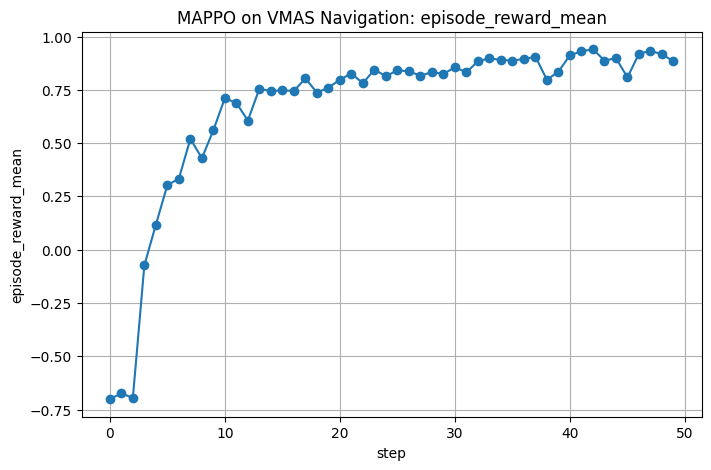

In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

root = Path(RUN_ROOT)
target = None
for p in root.rglob('collection_reward_episode_reward_mean.csv'):
    target = p
    break
print('target:', target)
df = pd.read_csv(target, header=None, names=['step', 'value'])
plt.figure(figsize=(8,5))
plt.plot(df['step'], df['value'], marker='o')
plt.xlabel('step')
plt.ylabel('episode_reward_mean')
plt.title('MAPPO on VMAS Navigation: episode_reward_mean')
plt.grid(True)
plt.show()

In [5]:
%%writefile src/run_curriculum_v1.py
from __future__ import annotations

import pathlib
import runpy
import sys
from dataclasses import dataclass


@dataclass
class CurriculumConfig:
    total_resets: int = 600
    easy_ratio: float = 0.30
    medium_ratio: float = 0.70
    easy_alpha: float = 0.35
    medium_alpha: float = 0.65
    verbose: bool = True


def _pop_arg(argv, name, default, cast):
    prefix = f"--{name}="
    flag = f"--{name}"
    kept = [argv[0]]
    value = default
    skip = False

    for i, item in enumerate(argv[1:], start=1):
        if skip:
            skip = False
            continue

        if item.startswith(prefix):
            value = cast(item[len(prefix):])
            continue

        if item == flag:
            if i + 1 >= len(argv):
                raise ValueError(f"Missing value for {flag}")
            value = cast(argv[i + 1])
            skip = True
            continue

        kept.append(item)

    argv[:] = kept
    return value


def parse_curriculum_args(argv):
    cfg = CurriculumConfig()
    cfg.total_resets = _pop_arg(argv, "cl-total-resets", cfg.total_resets, int)
    cfg.easy_ratio = _pop_arg(argv, "cl-easy-ratio", cfg.easy_ratio, float)
    cfg.medium_ratio = _pop_arg(argv, "cl-medium-ratio", cfg.medium_ratio, float)
    cfg.easy_alpha = _pop_arg(argv, "cl-easy-alpha", cfg.easy_alpha, float)
    cfg.medium_alpha = _pop_arg(argv, "cl-medium-alpha", cfg.medium_alpha, float)
    cfg.verbose = _pop_arg(argv, "cl-verbose", int(cfg.verbose), lambda x: int(x) != 0)

    if cfg.total_resets <= 0:
        raise ValueError("--cl-total-resets must be positive")
    if not (0.0 < cfg.easy_ratio < cfg.medium_ratio < 1.0):
        raise ValueError("Require 0 < easy_ratio < medium_ratio < 1")
    if not (0.0 < cfg.easy_alpha <= cfg.medium_alpha <= 1.0):
        raise ValueError("Require 0 < easy_alpha <= medium_alpha <= 1")

    return cfg


def find_navigation_py() -> pathlib.Path:
    candidates = [
        pathlib.Path("/usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py"),
        pathlib.Path("/usr/local/lib/python3.11/dist-packages/vmas/scenarios/navigation.py"),
        pathlib.Path("/usr/local/lib/python3.10/dist-packages/vmas/scenarios/navigation.py"),
        pathlib.Path("/usr/local/lib/python3.9/dist-packages/vmas/scenarios/navigation.py"),
        pathlib.Path("/usr/local/lib/python3.8/dist-packages/vmas/scenarios/navigation.py"),
    ]

    for path in candidates:
        if path.exists():
            return path

    raise FileNotFoundError("Could not locate VMAS navigation.py")


def strip_old_patches(src: str) -> str:
    markers = [
        "# [cl_patch]",
        "# [rs_patch]",
        "# [apf_aw_patch]",
        "# [apf_patch]",
    ]
    positions = [src.index(m) for m in markers if m in src]

    if positions:
        src = src[: min(positions)].rstrip()

    return src


def patch_navigation_curriculum(cfg: CurriculumConfig):
    nav_path = find_navigation_py()
    src = nav_path.read_text(encoding="utf-8")
    clean_src = strip_old_patches(src)

    if clean_src != src:
        print("[curriculum_v1] removed old rs/apf/cl patch from navigation.py")

    patch = f'''
# [cl_patch]
import torch as _torch

_cl_orig_reset = Scenario.reset_world_at
_cl_total_resets = {cfg.total_resets}
_cl_easy_ratio = {cfg.easy_ratio}
_cl_medium_ratio = {cfg.medium_ratio}
_cl_easy_alpha = {cfg.easy_alpha}
_cl_medium_alpha = {cfg.medium_alpha}
_cl_verbose = {cfg.verbose}


def _cl_get_phase(self):
    if not hasattr(self, "_cl_reset_count"):
        self._cl_reset_count = 0
        self._cl_last_phase = None

    progress = min(float(self._cl_reset_count) / max(float(_cl_total_resets), 1.0), 1.0)

    if progress < _cl_easy_ratio:
        return "easy", _cl_easy_alpha, progress
    if progress < _cl_medium_ratio:
        return "medium", _cl_medium_alpha, progress
    return "hard", 1.0, progress


def _cl_update_pos_shaping(self, agent, env_index=None):
    if not hasattr(agent, "pos_shaping") or not hasattr(agent, "goal"):
        return

    if env_index is None:
        agent.pos_shaping = (
            _torch.linalg.vector_norm(agent.state.pos - agent.goal.state.pos, dim=1)
            * self.pos_shaping_factor
        )
    else:
        agent.pos_shaping[env_index] = (
            _torch.linalg.vector_norm(
                agent.state.pos[env_index] - agent.goal.state.pos[env_index]
            )
            * self.pos_shaping_factor
        )


def _cl_reset(self, env_index=None):
    out = _cl_orig_reset(self, env_index)

    if not hasattr(self, "_cl_reset_count"):
        self._cl_reset_count = 0
        self._cl_last_phase = None

    self._cl_reset_count += 1
    phase, alpha, progress = _cl_get_phase(self)

    if _cl_verbose and phase != getattr(self, "_cl_last_phase", None):
        print(
            f"[curriculum_v1] phase={{phase}}, alpha={{alpha:.3f}}, "
            f"reset={{self._cl_reset_count}}/{{_cl_total_resets}}, "
            f"progress={{progress:.3f}}"
        )
        self._cl_last_phase = phase

    if phase == "hard":
        return out

    for agent in self.world.agents:
        if not hasattr(agent, "goal"):
            continue

        if env_index is None:
            agent_pos = agent.state.pos
            goal_pos = agent.goal.state.pos
            new_goal_pos = agent_pos + alpha * (goal_pos - agent_pos)
            agent.goal.set_pos(new_goal_pos, batch_index=env_index)
        else:
            agent_pos = agent.state.pos[env_index]
            goal_pos = agent.goal.state.pos[env_index]
            new_goal_pos = agent_pos + alpha * (goal_pos - agent_pos)
            agent.goal.set_pos(new_goal_pos, batch_index=env_index)

        _cl_update_pos_shaping(self, agent, env_index)

    return out


Scenario.reset_world_at = _cl_reset
print(
    "[cl_patch] curriculum patch applied: "
    f"total_resets={{_cl_total_resets}}, "
    f"easy_ratio={{_cl_easy_ratio}}, "
    f"medium_ratio={{_cl_medium_ratio}}, "
    f"easy_alpha={{_cl_easy_alpha}}, "
    f"medium_alpha={{_cl_medium_alpha}}"
)
'''

    nav_path.write_text(clean_src + "\n\n" + patch + "\n", encoding="utf-8")

    pycache_dir = nav_path.parent / "__pycache__"
    for pyc in pycache_dir.glob("navigation.cpython-*.pyc"):
        try:
            pyc.unlink()
        except Exception:
            pass

    print(f"[curriculum_v1] patched {nav_path}")


def main():
    cfg = parse_curriculum_args(sys.argv)
    patch_navigation_curriculum(cfg)

    sys.argv = ["benchmarl.run"] + sys.argv[1:]
    runpy.run_module("benchmarl.run", run_name="__main__")


if __name__ == "__main__":
    main()

Writing src/run_curriculum_v1.py


In [21]:
!python src/run_curriculum_v1.py \
  algorithm=mappo \
  task=vmas/navigation \
  experiment.render=false \
  experiment.evaluation=false \
  experiment.max_n_frames=30000 \
  seed=0 \
  --cl-total-resets=120

[curriculum_v1] removed old rs/apf/cl patch from navigation.py
[curriculum_v1] patched /usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py

Algorithm: mappo, Task: vmas/navigation

Loaded config:

experiment:
  sampling_device: cpu
  train_device: cpu
  buffer_device: cpu
  share_policy_params: true
  prefer_continuous_actions: true
  collect_with_grad: false
  parallel_collection: false
  gamma: 0.99
  lr: 5.0e-05
  adam_eps: 1.0e-06
  adam_extra_kwargs: {}
  clip_grad_norm: true
  clip_grad_val: 5.0
  soft_target_update: true
  polyak_tau: 0.005
  hard_target_update_frequency: 5
  exploration_eps_init: 0.8
  exploration_eps_end: 0.01
  exploration_anneal_frames: null
  max_n_iters: null
  max_n_frames: 30000
  on_policy_collected_frames_per_batch: 6000
  on_policy_n_envs_per_worker: 10
  on_policy_n_minibatch_iters: 45
  on_policy_minibatch_size: 400
  off_policy_collected_frames_per_batch: 6000
  off_policy_n_envs_per_worker: 10
  off_policy_n_optimizer_steps: 1000


In [4]:
import pathlib

candidates = [
    pathlib.Path("/usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py"),
    pathlib.Path("/usr/local/lib/python3.11/dist-packages/vmas/scenarios/navigation.py"),
    pathlib.Path("/usr/local/lib/python3.10/dist-packages/vmas/scenarios/navigation.py"),
    pathlib.Path("/usr/local/lib/python3.9/dist-packages/vmas/scenarios/navigation.py"),
    pathlib.Path("/usr/local/lib/python3.8/dist-packages/vmas/scenarios/navigation.py"),
]

nav_path = None
for p in candidates:
    if p.exists():
        nav_path = p
        break

print("navigation.py =", nav_path)

src = nav_path.read_text(encoding="utf-8")

markers = [
    "# [cl_patch]",
    "# [rs_patch]",
    "# [apf_aw_patch]",
    "# [apf_patch]",
]

positions = [src.index(m) for m in markers if m in src]

if positions:
    clean_src = src[:min(positions)].rstrip() + "\n"
    nav_path.write_text(clean_src, encoding="utf-8")
    print("Removed old patch from navigation.py")
else:
    print("No patch marker found")

pycache_dir = nav_path.parent / "__pycache__"
for pyc in pycache_dir.glob("navigation.cpython-*.pyc"):
    pyc.unlink()
    print("Deleted", pyc)

navigation.py = /usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py
Removed old patch from navigation.py
Deleted /usr/local/lib/python3.12/dist-packages/vmas/scenarios/__pycache__/navigation.cpython-312.pyc


In [5]:
!python -m benchmarl.run \
  algorithm=mappo \
  task=vmas/navigation \
  experiment.render=false \
  experiment.evaluation=false \
  experiment.max_n_frames=30000 \
  seed=0


Algorithm: mappo, Task: vmas/navigation

Loaded config:

experiment:
  sampling_device: cpu
  train_device: cpu
  buffer_device: cpu
  share_policy_params: true
  prefer_continuous_actions: true
  collect_with_grad: false
  parallel_collection: false
  gamma: 0.99
  lr: 5.0e-05
  adam_eps: 1.0e-06
  adam_extra_kwargs: {}
  clip_grad_norm: true
  clip_grad_val: 5.0
  soft_target_update: true
  polyak_tau: 0.005
  hard_target_update_frequency: 5
  exploration_eps_init: 0.8
  exploration_eps_end: 0.01
  exploration_anneal_frames: null
  max_n_iters: null
  max_n_frames: 30000
  on_policy_collected_frames_per_batch: 6000
  on_policy_n_envs_per_worker: 10
  on_policy_n_minibatch_iters: 45
  on_policy_minibatch_size: 400
  off_policy_collected_frames_per_batch: 6000
  off_policy_n_envs_per_worker: 10
  off_policy_n_optimizer_steps: 1000
  off_policy_train_batch_size: 128
  off_policy_memory_size: 1000000
  off_policy_init_random_frames: 0
  off_policy_use_prioritized_replay_buffer: false
  

In [9]:
import pathlib

candidates = [
    pathlib.Path("/usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py"),
    pathlib.Path("/usr/local/lib/python3.11/dist-packages/vmas/scenarios/navigation.py"),
    pathlib.Path("/usr/local/lib/python3.10/dist-packages/vmas/scenarios/navigation.py"),
]

nav_path = next(p for p in candidates if p.exists())
src = nav_path.read_text(encoding="utf-8")

markers = ["# [cl_patch]", "# [rs_patch]", "# [apf_aw_patch]", "# [apf_patch]"]
positions = [src.index(m) for m in markers if m in src]

if positions:
    nav_path.write_text(src[:min(positions)].rstrip() + "\n", encoding="utf-8")
    print("Removed patch from", nav_path)
else:
    print("No patch found")

pycache_dir = nav_path.parent / "__pycache__"
for pyc in pycache_dir.glob("navigation.cpython-*.pyc"):
    pyc.unlink()
    print("Deleted", pyc)

Removed patch from /usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py
Deleted /usr/local/lib/python3.12/dist-packages/vmas/scenarios/__pycache__/navigation.cpython-312.pyc


In [10]:
import pathlib

candidates = [
    pathlib.Path("/usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py"),
    pathlib.Path("/usr/local/lib/python3.11/dist-packages/vmas/scenarios/navigation.py"),
    pathlib.Path("/usr/local/lib/python3.10/dist-packages/vmas/scenarios/navigation.py"),
]

for p in candidates:
    if p.exists():
        src = p.read_text(encoding="utf-8")
        print("navigation.py =", p)
        print("has cl_patch:", "# [cl_patch]" in src)
        print("has rs_patch:", "# [rs_patch]" in src)
        print("has apf_patch:", "# [apf_patch]" in src or "# [apf_aw_patch]" in src)

navigation.py = /usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py
has cl_patch: False
has rs_patch: False
has apf_patch: False


In [11]:
!python src/run_curriculum_v1.py \
  algorithm=mappo \
  task=vmas/navigation \
  experiment.render=false \
  experiment.evaluation=false \
  experiment.max_n_frames=30000 \
  seed=1 \
  --cl-total-resets=120

[curriculum_v1] patched /usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py

Algorithm: mappo, Task: vmas/navigation

Loaded config:

experiment:
  sampling_device: cpu
  train_device: cpu
  buffer_device: cpu
  share_policy_params: true
  prefer_continuous_actions: true
  collect_with_grad: false
  parallel_collection: false
  gamma: 0.99
  lr: 5.0e-05
  adam_eps: 1.0e-06
  adam_extra_kwargs: {}
  clip_grad_norm: true
  clip_grad_val: 5.0
  soft_target_update: true
  polyak_tau: 0.005
  hard_target_update_frequency: 5
  exploration_eps_init: 0.8
  exploration_eps_end: 0.01
  exploration_anneal_frames: null
  max_n_iters: null
  max_n_frames: 30000
  on_policy_collected_frames_per_batch: 6000
  on_policy_n_envs_per_worker: 10
  on_policy_n_minibatch_iters: 45
  on_policy_minibatch_size: 400
  off_policy_collected_frames_per_batch: 6000
  off_policy_n_envs_per_worker: 10
  off_policy_n_optimizer_steps: 1000
  off_policy_train_batch_size: 128
  off_policy_memory_size: 10

In [12]:
import pathlib

candidates = [
    pathlib.Path("/usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py"),
    pathlib.Path("/usr/local/lib/python3.11/dist-packages/vmas/scenarios/navigation.py"),
    pathlib.Path("/usr/local/lib/python3.10/dist-packages/vmas/scenarios/navigation.py"),
]

nav_path = next(p for p in candidates if p.exists())
src = nav_path.read_text(encoding="utf-8")

markers = ["# [cl_patch]", "# [rs_patch]", "# [apf_aw_patch]", "# [apf_patch]"]
positions = [src.index(m) for m in markers if m in src]

if positions:
    nav_path.write_text(src[:min(positions)].rstrip() + "\n", encoding="utf-8")
    print("Removed patch from", nav_path)
else:
    print("No patch found")

pycache_dir = nav_path.parent / "__pycache__"
for pyc in pycache_dir.glob("navigation.cpython-*.pyc"):
    pyc.unlink()
    print("Deleted", pyc)

Removed patch from /usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py
Deleted /usr/local/lib/python3.12/dist-packages/vmas/scenarios/__pycache__/navigation.cpython-312.pyc


In [13]:
!python -m benchmarl.run \
  algorithm=mappo \
  task=vmas/navigation \
  experiment.render=false \
  experiment.evaluation=false \
  experiment.max_n_frames=30000 \
  seed=1


Algorithm: mappo, Task: vmas/navigation

Loaded config:

experiment:
  sampling_device: cpu
  train_device: cpu
  buffer_device: cpu
  share_policy_params: true
  prefer_continuous_actions: true
  collect_with_grad: false
  parallel_collection: false
  gamma: 0.99
  lr: 5.0e-05
  adam_eps: 1.0e-06
  adam_extra_kwargs: {}
  clip_grad_norm: true
  clip_grad_val: 5.0
  soft_target_update: true
  polyak_tau: 0.005
  hard_target_update_frequency: 5
  exploration_eps_init: 0.8
  exploration_eps_end: 0.01
  exploration_anneal_frames: null
  max_n_iters: null
  max_n_frames: 30000
  on_policy_collected_frames_per_batch: 6000
  on_policy_n_envs_per_worker: 10
  on_policy_n_minibatch_iters: 45
  on_policy_minibatch_size: 400
  off_policy_collected_frames_per_batch: 6000
  off_policy_n_envs_per_worker: 10
  off_policy_n_optimizer_steps: 1000
  off_policy_train_batch_size: 128
  off_policy_memory_size: 1000000
  off_policy_init_random_frames: 0
  off_policy_use_prioritized_replay_buffer: false
  

In [3]:
import pathlib

candidates = [
    pathlib.Path("/usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py"),
    pathlib.Path("/usr/local/lib/python3.11/dist-packages/vmas/scenarios/navigation.py"),
    pathlib.Path("/usr/local/lib/python3.10/dist-packages/vmas/scenarios/navigation.py"),
]

nav_path = next(p for p in candidates if p.exists())
src = nav_path.read_text(encoding="utf-8")

markers = ["# [cl_patch]", "# [rs_patch]", "# [apf_aw_patch]", "# [apf_patch]"]
positions = [src.index(m) for m in markers if m in src]

if positions:
    nav_path.write_text(src[:min(positions)].rstrip() + "\n", encoding="utf-8")
    print("Removed patch from", nav_path)
else:
    print("No patch found")

pycache_dir = nav_path.parent / "__pycache__"
for pyc in pycache_dir.glob("navigation.cpython-*.pyc"):
    pyc.unlink()
    print("Deleted", pyc)

src = nav_path.read_text(encoding="utf-8")
print("has cl_patch:", "# [cl_patch]" in src)
print("has rs_patch:", "# [rs_patch]" in src)
print("has apf_patch:", "# [apf_patch]" in src or "# [apf_aw_patch]" in src)

No patch found
Deleted /usr/local/lib/python3.12/dist-packages/vmas/scenarios/__pycache__/navigation.cpython-312.pyc
has cl_patch: False
has rs_patch: False
has apf_patch: False


In [4]:
!python -m benchmarl.run \
  algorithm=mappo \
  task=vmas/navigation \
  experiment.render=false \
  experiment.evaluation=false \
  experiment.max_n_frames=100000 \
  seed=0


Algorithm: mappo, Task: vmas/navigation

Loaded config:

experiment:
  sampling_device: cpu
  train_device: cpu
  buffer_device: cpu
  share_policy_params: true
  prefer_continuous_actions: true
  collect_with_grad: false
  parallel_collection: false
  gamma: 0.99
  lr: 5.0e-05
  adam_eps: 1.0e-06
  adam_extra_kwargs: {}
  clip_grad_norm: true
  clip_grad_val: 5.0
  soft_target_update: true
  polyak_tau: 0.005
  hard_target_update_frequency: 5
  exploration_eps_init: 0.8
  exploration_eps_end: 0.01
  exploration_anneal_frames: null
  max_n_iters: null
  max_n_frames: 100000
  on_policy_collected_frames_per_batch: 6000
  on_policy_n_envs_per_worker: 10
  on_policy_n_minibatch_iters: 45
  on_policy_minibatch_size: 400
  off_policy_collected_frames_per_batch: 6000
  off_policy_n_envs_per_worker: 10
  off_policy_n_optimizer_steps: 1000
  off_policy_train_batch_size: 128
  off_policy_memory_size: 1000000
  off_policy_init_random_frames: 0
  off_policy_use_prioritized_replay_buffer: false
 

In [7]:
!python src/run_curriculum_v1.py \
  algorithm=mappo \
  task=vmas/navigation \
  experiment.render=false \
  experiment.evaluation=false \
  experiment.max_n_frames=100000 \
  seed=0 \
  --cl-total-resets=400

[curriculum_v1] patched /usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py

Algorithm: mappo, Task: vmas/navigation

Loaded config:

experiment:
  sampling_device: cpu
  train_device: cpu
  buffer_device: cpu
  share_policy_params: true
  prefer_continuous_actions: true
  collect_with_grad: false
  parallel_collection: false
  gamma: 0.99
  lr: 5.0e-05
  adam_eps: 1.0e-06
  adam_extra_kwargs: {}
  clip_grad_norm: true
  clip_grad_val: 5.0
  soft_target_update: true
  polyak_tau: 0.005
  hard_target_update_frequency: 5
  exploration_eps_init: 0.8
  exploration_eps_end: 0.01
  exploration_anneal_frames: null
  max_n_iters: null
  max_n_frames: 100000
  on_policy_collected_frames_per_batch: 6000
  on_policy_n_envs_per_worker: 10
  on_policy_n_minibatch_iters: 45
  on_policy_minibatch_size: 400
  off_policy_collected_frames_per_batch: 6000
  off_policy_n_envs_per_worker: 10
  off_policy_n_optimizer_steps: 1000
  off_policy_train_batch_size: 128
  off_policy_memory_size: 1

In [8]:
import pathlib

candidates = [
    pathlib.Path("/usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py"),
    pathlib.Path("/usr/local/lib/python3.11/dist-packages/vmas/scenarios/navigation.py"),
    pathlib.Path("/usr/local/lib/python3.10/dist-packages/vmas/scenarios/navigation.py"),
]

nav_path = next(p for p in candidates if p.exists())
src = nav_path.read_text(encoding="utf-8")

markers = ["# [cl_patch]", "# [rs_patch]", "# [apf_aw_patch]", "# [apf_patch]"]
positions = [src.index(m) for m in markers if m in src]

if positions:
    nav_path.write_text(src[:min(positions)].rstrip() + "\n", encoding="utf-8")
    print("Removed patch from", nav_path)
else:
    print("No patch found")

pycache_dir = nav_path.parent / "__pycache__"
for pyc in pycache_dir.glob("navigation.cpython-*.pyc"):
    pyc.unlink()
    print("Deleted", pyc)

src = nav_path.read_text(encoding="utf-8")
print("has cl_patch:", "# [cl_patch]" in src)
print("has rs_patch:", "# [rs_patch]" in src)
print("has apf_patch:", "# [apf_patch]" in src or "# [apf_aw_patch]" in src)

Removed patch from /usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py
Deleted /usr/local/lib/python3.12/dist-packages/vmas/scenarios/__pycache__/navigation.cpython-312.pyc
has cl_patch: False
has rs_patch: False
has apf_patch: False


In [9]:
!python -m benchmarl.run \
  algorithm=mappo \
  task=vmas/navigation \
  experiment.render=false \
  experiment.evaluation=false \
  experiment.max_n_frames=100000 \
  seed=1


Algorithm: mappo, Task: vmas/navigation

Loaded config:

experiment:
  sampling_device: cpu
  train_device: cpu
  buffer_device: cpu
  share_policy_params: true
  prefer_continuous_actions: true
  collect_with_grad: false
  parallel_collection: false
  gamma: 0.99
  lr: 5.0e-05
  adam_eps: 1.0e-06
  adam_extra_kwargs: {}
  clip_grad_norm: true
  clip_grad_val: 5.0
  soft_target_update: true
  polyak_tau: 0.005
  hard_target_update_frequency: 5
  exploration_eps_init: 0.8
  exploration_eps_end: 0.01
  exploration_anneal_frames: null
  max_n_iters: null
  max_n_frames: 100000
  on_policy_collected_frames_per_batch: 6000
  on_policy_n_envs_per_worker: 10
  on_policy_n_minibatch_iters: 45
  on_policy_minibatch_size: 400
  off_policy_collected_frames_per_batch: 6000
  off_policy_n_envs_per_worker: 10
  off_policy_n_optimizer_steps: 1000
  off_policy_train_batch_size: 128
  off_policy_memory_size: 1000000
  off_policy_init_random_frames: 0
  off_policy_use_prioritized_replay_buffer: false
 

In [10]:
!python src/run_curriculum_v1.py \
  algorithm=mappo \
  task=vmas/navigation \
  experiment.render=false \
  experiment.evaluation=false \
  experiment.max_n_frames=100000 \
  seed=1 \
  --cl-total-resets=400

[curriculum_v1] patched /usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py

Algorithm: mappo, Task: vmas/navigation

Loaded config:

experiment:
  sampling_device: cpu
  train_device: cpu
  buffer_device: cpu
  share_policy_params: true
  prefer_continuous_actions: true
  collect_with_grad: false
  parallel_collection: false
  gamma: 0.99
  lr: 5.0e-05
  adam_eps: 1.0e-06
  adam_extra_kwargs: {}
  clip_grad_norm: true
  clip_grad_val: 5.0
  soft_target_update: true
  polyak_tau: 0.005
  hard_target_update_frequency: 5
  exploration_eps_init: 0.8
  exploration_eps_end: 0.01
  exploration_anneal_frames: null
  max_n_iters: null
  max_n_frames: 100000
  on_policy_collected_frames_per_batch: 6000
  on_policy_n_envs_per_worker: 10
  on_policy_n_minibatch_iters: 45
  on_policy_minibatch_size: 400
  off_policy_collected_frames_per_batch: 6000
  off_policy_n_envs_per_worker: 10
  off_policy_n_optimizer_steps: 1000
  off_policy_train_batch_size: 128
  off_policy_memory_size: 1

In [6]:
import pathlib

candidates = [
    pathlib.Path("/usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py"),
    pathlib.Path("/usr/local/lib/python3.11/dist-packages/vmas/scenarios/navigation.py"),
    pathlib.Path("/usr/local/lib/python3.10/dist-packages/vmas/scenarios/navigation.py"),
]

nav_path = next(p for p in candidates if p.exists())
src = nav_path.read_text(encoding="utf-8")

markers = ["# [cl_patch]", "# [rs_patch]", "# [apf_aw_patch]", "# [apf_patch]"]
positions = [src.index(m) for m in markers if m in src]

if positions:
    nav_path.write_text(src[:min(positions)].rstrip() + "\n", encoding="utf-8")
    print("Removed patch from", nav_path)
else:
    print("No patch found")

pycache_dir = nav_path.parent / "__pycache__"
for pyc in pycache_dir.glob("navigation.cpython-*.pyc"):
    pyc.unlink()
    print("Deleted", pyc)

src = nav_path.read_text(encoding="utf-8")
print("has cl_patch:", "# [cl_patch]" in src)
print("has rs_patch:", "# [rs_patch]" in src)
print("has apf_patch:", "# [apf_patch]" in src or "# [apf_aw_patch]" in src)

No patch found
Deleted /usr/local/lib/python3.12/dist-packages/vmas/scenarios/__pycache__/navigation.cpython-312.pyc
has cl_patch: False
has rs_patch: False
has apf_patch: False


In [9]:
!WANDB_MODE=offline python -m benchmarl.run \
  algorithm=mappo \
  task=vmas/navigation \
  experiment.render=false \
  experiment.evaluation=false \
  experiment.max_n_frames=100000 \
  seed=2 2>&1 | tee baseline_100k_seed2.log

/usr/local/lib/python3.12/dist-packages/torchrl/collectors/_base.py:1045: DeprecationWarning: SyncDataCollector has been deprecated and will be removed in v0.13. Please use Collector instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchrl/collectors/_single.py:911: UserWarning: total_frames (100000) is not exactly divisible by frames_per_batch (6000). This means 2000 additional frames will be collected.To silence this message, set the environment variable RL_WARNINGS to False.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/wandb/analytics/sentry.py:268: DeprecationWarning: Read the `app_url` setting from the appropriate Settings object.
  app_url = wandb.util.app_url(tags["base_url"])  # type: ignore[index]
]11;?wandb: WARNING `resume` will be ignored since W&B syncing is set to `offline`. Starting a new run with run id mappo_navigation_mlp__ffc2e207_26_04_27-01_51_22.
/usr/local/lib/python3.12/dist-packages/wandb/analytics/sentry.py:268: DeprecationWarnin

In [10]:
baseline_100k_seed2 = extract_metrics_from_log("baseline_100k_seed2.log")

===== Extracted Metrics =====
log_path        : baseline_100k_seed2.log
Reward          : 0.95661
Pos_Rew         : 0.01312
Agent_Collisions: -0.00056
Collision_Risk  : 0.00056
Final_Rew       : 0.0


In [13]:
!WANDB_MODE=offline python src/run_curriculum_v1.py \
  algorithm=mappo \
  task=vmas/navigation \
  experiment.render=false \
  experiment.evaluation=false \
  experiment.max_n_frames=100000 \
  seed=2 \
  --cl-total-resets=400 2>&1 | tee cl_100k_seed2.log

[curriculum_v1] patched /usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py
/usr/local/lib/python3.12/dist-packages/torchrl/collectors/_base.py:1045: DeprecationWarning: SyncDataCollector has been deprecated and will be removed in v0.13. Please use Collector instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchrl/collectors/_single.py:911: UserWarning: total_frames (100000) is not exactly divisible by frames_per_batch (6000). This means 2000 additional frames will be collected.To silence this message, set the environment variable RL_WARNINGS to False.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/wandb/analytics/sentry.py:268: DeprecationWarning: Read the `app_url` setting from the appropriate Settings object.
  app_url = wandb.util.app_url(tags["base_url"])  # type: ignore[index]
]11;?wandb: WARNING `resume` will be ignored since W&B syncing is set to `offline`. Starting a new run with run id mappo_navigation_mlp__1017566c_26_04_27-01_56

In [15]:
cl_100k_seed2 = extract_metrics_from_log("cl_100k_seed2.log")

===== Extracted Metrics =====
log_path        : cl_100k_seed2.log
Reward          : 0.71386
Pos_Rew         : 0.01136
Agent_Collisions: -0.00256
Collision_Risk  : 0.00256
Final_Rew       : 0.0


In [16]:
import pathlib

candidates = [
    pathlib.Path("/usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py"),
    pathlib.Path("/usr/local/lib/python3.11/dist-packages/vmas/scenarios/navigation.py"),
    pathlib.Path("/usr/local/lib/python3.10/dist-packages/vmas/scenarios/navigation.py"),
]

nav_path = next(p for p in candidates if p.exists())
src = nav_path.read_text(encoding="utf-8")

markers = ["# [cl_patch]", "# [rs_patch]", "# [apf_aw_patch]", "# [apf_patch]"]
positions = [src.index(m) for m in markers if m in src]

if positions:
    nav_path.write_text(src[:min(positions)].rstrip() + "\n", encoding="utf-8")
    print("Removed patch from", nav_path)
else:
    print("No patch found")

pycache_dir = nav_path.parent / "__pycache__"
for pyc in pycache_dir.glob("navigation.cpython-*.pyc"):
    pyc.unlink()
    print("Deleted", pyc)

src = nav_path.read_text(encoding="utf-8")
print("has cl_patch:", "# [cl_patch]" in src)
print("has rs_patch:", "# [rs_patch]" in src)
print("has apf_patch:", "# [apf_patch]" in src or "# [apf_aw_patch]" in src)

Removed patch from /usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py
Deleted /usr/local/lib/python3.12/dist-packages/vmas/scenarios/__pycache__/navigation.cpython-312.pyc
has cl_patch: False
has rs_patch: False
has apf_patch: False


60000 Seed=0

In [17]:
!WANDB_MODE=offline python -m benchmarl.run \
  algorithm=mappo \
  task=vmas/navigation \
  experiment.render=false \
  experiment.evaluation=false \
  experiment.max_n_frames=60000 \
  seed=0 2>&1 | tee baseline_60k_seed0.log

/usr/local/lib/python3.12/dist-packages/torchrl/collectors/_base.py:1045: DeprecationWarning: SyncDataCollector has been deprecated and will be removed in v0.13. Please use Collector instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/wandb/analytics/sentry.py:268: DeprecationWarning: Read the `app_url` setting from the appropriate Settings object.
  app_url = wandb.util.app_url(tags["base_url"])  # type: ignore[index]
]11;?wandb: WARNING `resume` will be ignored since W&B syncing is set to `offline`. Starting a new run with run id mappo_navigation_mlp__ab783097_26_04_27-02_01_20.
/usr/local/lib/python3.12/dist-packages/wandb/analytics/sentry.py:268: DeprecationWarning: Read the `app_url` setting from the appropriate Settings object.
  app_url = wandb.util.app_url(tags["base_url"])  # type: ignore[index]
wandb: Tracking run with wandb version 0.25.1
wandb: W&B syncing is set to `offline` in this directory. Run `wandb online` or set WANDB_MODE=online to enable cloud sync

In [18]:
baseline_60k_seed0 = extract_metrics_from_log("baseline_60k_seed0.log")

===== Extracted Metrics =====
log_path        : baseline_60k_seed0.log
Reward          : 0.85421
Pos_Rew         : 0.00894
Agent_Collisions: -0.00033
Collision_Risk  : 0.00033
Final_Rew       : 0.0


In [19]:
!WANDB_MODE=offline python src/run_curriculum_v1.py \
  algorithm=mappo \
  task=vmas/navigation \
  experiment.render=false \
  experiment.evaluation=false \
  experiment.max_n_frames=60000 \
  seed=0 \
  --cl-total-resets=240 2>&1 | tee cl_60k_seed0.log

[curriculum_v1] patched /usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py
/usr/local/lib/python3.12/dist-packages/torchrl/collectors/_base.py:1045: DeprecationWarning: SyncDataCollector has been deprecated and will be removed in v0.13. Please use Collector instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/wandb/analytics/sentry.py:268: DeprecationWarning: Read the `app_url` setting from the appropriate Settings object.
  app_url = wandb.util.app_url(tags["base_url"])  # type: ignore[index]
]11;?wandb: WARNING `resume` will be ignored since W&B syncing is set to `offline`. Starting a new run with run id mappo_navigation_mlp__399bec0a_26_04_27-02_03_52.
/usr/local/lib/python3.12/dist-packages/wandb/analytics/sentry.py:268: DeprecationWarning: Read the `app_url` setting from the appropriate Settings object.
  app_url = wandb.util.app_url(tags["base_url"])  # type: ignore[index]
wandb: Tracking run with wandb version 0.25.1
wandb: W&B syncing is set to 

In [20]:
cl_60k_seed0 = extract_metrics_from_log("cl_60k_seed0.log")

===== Extracted Metrics =====
log_path        : cl_60k_seed0.log
Reward          : 0.67481
Pos_Rew         : 0.00965
Agent_Collisions: -0.00244
Collision_Risk  : 0.00244
Final_Rew       : 0.0


In [21]:
import pathlib

candidates = [
    pathlib.Path("/usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py"),
    pathlib.Path("/usr/local/lib/python3.11/dist-packages/vmas/scenarios/navigation.py"),
    pathlib.Path("/usr/local/lib/python3.10/dist-packages/vmas/scenarios/navigation.py"),
]

nav_path = next(p for p in candidates if p.exists())
src = nav_path.read_text(encoding="utf-8")

markers = ["# [cl_patch]", "# [rs_patch]", "# [apf_aw_patch]", "# [apf_patch]"]
positions = [src.index(m) for m in markers if m in src]

if positions:
    nav_path.write_text(src[:min(positions)].rstrip() + "\n", encoding="utf-8")
    print("Removed patch from", nav_path)
else:
    print("No patch found")

pycache_dir = nav_path.parent / "__pycache__"
for pyc in pycache_dir.glob("navigation.cpython-*.pyc"):
    pyc.unlink()
    print("Deleted", pyc)

src = nav_path.read_text(encoding="utf-8")
print("has cl_patch:", "# [cl_patch]" in src)
print("has rs_patch:", "# [rs_patch]" in src)
print("has apf_patch:", "# [apf_patch]" in src or "# [apf_aw_patch]" in src)

Removed patch from /usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py
Deleted /usr/local/lib/python3.12/dist-packages/vmas/scenarios/__pycache__/navigation.cpython-312.pyc
has cl_patch: False
has rs_patch: False
has apf_patch: False


6000 Seed=0 Fast

In [6]:
!WANDB_MODE=offline python src/run_curriculum_v1.py \
  algorithm=mappo \
  task=vmas/navigation \
  experiment.render=false \
  experiment.evaluation=false \
  experiment.max_n_frames=60000 \
  seed=0 \
  --cl-total-resets=240 \
  --cl-easy-ratio=0.15 \
  --cl-medium-ratio=0.40 2>&1 | tee cl_fast_60k_seed0.log

[curriculum_v1] patched /usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py
/usr/local/lib/python3.12/dist-packages/torchrl/collectors/_base.py:1045: DeprecationWarning: SyncDataCollector has been deprecated and will be removed in v0.13. Please use Collector instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/wandb/analytics/sentry.py:268: DeprecationWarning: Read the `app_url` setting from the appropriate Settings object.
  app_url = wandb.util.app_url(tags["base_url"])  # type: ignore[index]
]11;?wandb: WARNING `resume` will be ignored since W&B syncing is set to `offline`. Starting a new run with run id mappo_navigation_mlp__06b9b3e5_26_04_27-12_48_46.
/usr/local/lib/python3.12/dist-packages/wandb/analytics/sentry.py:268: DeprecationWarning: Read the `app_url` setting from the appropriate Settings object.
  app_url = wandb.util.app_url(tags["base_url"])  # type: ignore[index]
wandb: Tracking run with wandb version 0.25.1
wandb: W&B syncing is set to 

In [10]:
cl_fast_60k_seed0 = extract_metrics_from_log("cl_fast_60k_seed0.log")

===== Extracted Metrics =====
log_path        : cl_fast_60k_seed0.log
Reward          : 0.63755
Pos_Rew         : 0.00981
Agent_Collisions: -0.00322
Collision_Risk  : 0.00322
Final_Rew       : 0.0


60000 Seed=1

In [12]:
!WANDB_MODE=offline python -m benchmarl.run \
  algorithm=mappo \
  task=vmas/navigation \
  experiment.render=false \
  experiment.evaluation=false \
  experiment.max_n_frames=60000 \
  seed=1 2>&1 | tee baseline_60k_seed1.log

/usr/local/lib/python3.12/dist-packages/torchrl/collectors/_base.py:1045: DeprecationWarning: SyncDataCollector has been deprecated and will be removed in v0.13. Please use Collector instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/wandb/analytics/sentry.py:268: DeprecationWarning: Read the `app_url` setting from the appropriate Settings object.
  app_url = wandb.util.app_url(tags["base_url"])  # type: ignore[index]
]11;?wandb: WARNING `resume` will be ignored since W&B syncing is set to `offline`. Starting a new run with run id mappo_navigation_mlp__3f3b1203_26_04_27-12_54_03.
/usr/local/lib/python3.12/dist-packages/wandb/analytics/sentry.py:268: DeprecationWarning: Read the `app_url` setting from the appropriate Settings object.
  app_url = wandb.util.app_url(tags["base_url"])  # type: ignore[index]
wandb: Tracking run with wandb version 0.25.1
wandb: W&B syncing is set to `offline` in this directory. Run `wandb online` or set WANDB_MODE=online to enable cloud sync

In [11]:
baseline_60k_seed1 = extract_metrics_from_log("baseline_60k_seed1.log")

FileNotFoundError: [Errno 2] No such file or directory: 'baseline_60k_seed1.log'

In [ ]:
!WANDB_MODE=offline python src/run_curriculum_v1.py \
  algorithm=mappo \
  task=vmas/navigation \
  experiment.render=false \
  experiment.evaluation=false \
  experiment.max_n_frames=60000 \
  seed=1 \
  --cl-total-resets=240 2>&1 | tee cl_60k_seed1.log

In [ ]:
cl_60k_seed1 = extract_metrics_from_log("cl_60k_seed1.log")

In [ ]:
import pathlib

candidates = [
    pathlib.Path("/usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py"),
    pathlib.Path("/usr/local/lib/python3.11/dist-packages/vmas/scenarios/navigation.py"),
    pathlib.Path("/usr/local/lib/python3.10/dist-packages/vmas/scenarios/navigation.py"),
]

nav_path = next(p for p in candidates if p.exists())
src = nav_path.read_text(encoding="utf-8")

markers = ["# [cl_patch]", "# [rs_patch]", "# [apf_aw_patch]", "# [apf_patch]"]
positions = [src.index(m) for m in markers if m in src]

if positions:
    nav_path.write_text(src[:min(positions)].rstrip() + "\n", encoding="utf-8")
    print("Removed patch from", nav_path)
else:
    print("No patch found")

pycache_dir = nav_path.parent / "__pycache__"
for pyc in pycache_dir.glob("navigation.cpython-*.pyc"):
    pyc.unlink()
    print("Deleted", pyc)

src = nav_path.read_text(encoding="utf-8")
print("has cl_patch:", "# [cl_patch]" in src)
print("has rs_patch:", "# [rs_patch]" in src)
print("has apf_patch:", "# [apf_patch]" in src or "# [apf_aw_patch]" in src)

No patch found
Deleted /usr/local/lib/python3.12/dist-packages/vmas/scenarios/__pycache__/navigation.cpython-312.pyc
has cl_patch: False
has rs_patch: False
has apf_patch: False


60000 Seed=2

In [ ]:
!WANDB_MODE=offline python -m benchmarl.run \
  algorithm=mappo \
  task=vmas/navigation \
  experiment.render=false \
  experiment.evaluation=false \
  experiment.max_n_frames=60000 \
  seed=2 2>&1 | tee baseline_60k_seed2.log

In [ ]:
baseline_60k_seed2 = extract_metrics_from_log("baseline_60k_seed2.log")

In [ ]:
!WANDB_MODE=offline python src/run_curriculum_v1.py \
  algorithm=mappo \
  task=vmas/navigation \
  experiment.render=false \
  experiment.evaluation=false \
  experiment.max_n_frames=60000 \
  seed=2 \
  --cl-total-resets=240 2>&1 | tee cl_60k_seed2.log

In [ ]:
cl_60k_seed2 = extract_metrics_from_log("cl_60k_seed2.log")

In [13]:
import pathlib

candidates = [
    pathlib.Path("/usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py"),
    pathlib.Path("/usr/local/lib/python3.11/dist-packages/vmas/scenarios/navigation.py"),
    pathlib.Path("/usr/local/lib/python3.10/dist-packages/vmas/scenarios/navigation.py"),
]

nav_path = next(p for p in candidates if p.exists())
src = nav_path.read_text(encoding="utf-8")

markers = ["# [cl_patch]", "# [rs_patch]", "# [apf_aw_patch]", "# [apf_patch]"]
positions = [src.index(m) for m in markers if m in src]

if positions:
    nav_path.write_text(src[:min(positions)].rstrip() + "\n", encoding="utf-8")
    print("Removed patch from", nav_path)
else:
    print("No patch found")

pycache_dir = nav_path.parent / "__pycache__"
for pyc in pycache_dir.glob("navigation.cpython-*.pyc"):
    pyc.unlink()
    print("Deleted", pyc)

src = nav_path.read_text(encoding="utf-8")
print("has cl_patch:", "# [cl_patch]" in src)
print("has rs_patch:", "# [rs_patch]" in src)
print("has apf_patch:", "# [apf_patch]" in src or "# [apf_aw_patch]" in src)

Removed patch from /usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py
Deleted /usr/local/lib/python3.12/dist-packages/vmas/scenarios/__pycache__/navigation.cpython-312.pyc
has cl_patch: False
has rs_patch: False
has apf_patch: False


30000 seed =2

In [14]:
!WANDB_MODE=offline python -m benchmarl.run \
  algorithm=mappo \
  task=vmas/navigation \
  experiment.render=false \
  experiment.evaluation=false \
  experiment.max_n_frames=30000 \
  seed=2 2>&1 | tee baseline_30k_seed2.log

/usr/local/lib/python3.12/dist-packages/torchrl/collectors/_base.py:1045: DeprecationWarning: SyncDataCollector has been deprecated and will be removed in v0.13. Please use Collector instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/wandb/analytics/sentry.py:268: DeprecationWarning: Read the `app_url` setting from the appropriate Settings object.
  app_url = wandb.util.app_url(tags["base_url"])  # type: ignore[index]
]11;?wandb: WARNING `resume` will be ignored since W&B syncing is set to `offline`. Starting a new run with run id mappo_navigation_mlp__000231d1_26_04_27-12_57_15.
/usr/local/lib/python3.12/dist-packages/wandb/analytics/sentry.py:268: DeprecationWarning: Read the `app_url` setting from the appropriate Settings object.
  app_url = wandb.util.app_url(tags["base_url"])  # type: ignore[index]
wandb: Tracking run with wandb version 0.25.1
wandb: W&B syncing is set to `offline` in this directory. Run `wandb online` or set WANDB_MODE=online to enable cloud sync

In [15]:
baseline_30k_seed2 = extract_metrics_from_log("baseline_30k_seed2.log")

===== Extracted Metrics =====
log_path        : baseline_30k_seed2.log
Reward          : 0.42486
Pos_Rew         : 0.00569
Agent_Collisions: -0.00144
Collision_Risk  : 0.00144
Final_Rew       : 0.0


In [16]:
!WANDB_MODE=offline python src/run_curriculum_v1.py \
  algorithm=mappo \
  task=vmas/navigation \
  experiment.render=false \
  experiment.evaluation=false \
  experiment.max_n_frames=30000 \
  seed=2 \
  --cl-total-resets=120 2>&1 | tee cl_30k_seed2.log

[curriculum_v1] patched /usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py
/usr/local/lib/python3.12/dist-packages/torchrl/collectors/_base.py:1045: DeprecationWarning: SyncDataCollector has been deprecated and will be removed in v0.13. Please use Collector instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/wandb/analytics/sentry.py:268: DeprecationWarning: Read the `app_url` setting from the appropriate Settings object.
  app_url = wandb.util.app_url(tags["base_url"])  # type: ignore[index]
]11;?wandb: WARNING `resume` will be ignored since W&B syncing is set to `offline`. Starting a new run with run id mappo_navigation_mlp__da904104_26_04_27-12_58_37.
/usr/local/lib/python3.12/dist-packages/wandb/analytics/sentry.py:268: DeprecationWarning: Read the `app_url` setting from the appropriate Settings object.
  app_url = wandb.util.app_url(tags["base_url"])  # type: ignore[index]
wandb: Tracking run with wandb version 0.25.1
wandb: W&B syncing is set to 

In [17]:
cl_30k_seed2 = extract_metrics_from_log("cl_30k_seed2.log")

===== Extracted Metrics =====
log_path        : cl_30k_seed2.log
Reward          : 0.10182
Pos_Rew         : 0.00907
Agent_Collisions: -0.00822
Collision_Risk  : 0.00822
Final_Rew       : 0.0


40k Seed=0

In [18]:
import pathlib

candidates = [
    pathlib.Path("/usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py"),
    pathlib.Path("/usr/local/lib/python3.11/dist-packages/vmas/scenarios/navigation.py"),
    pathlib.Path("/usr/local/lib/python3.10/dist-packages/vmas/scenarios/navigation.py"),
]

nav_path = next(p for p in candidates if p.exists())
src = nav_path.read_text(encoding="utf-8")

markers = ["# [cl_patch]", "# [rs_patch]", "# [apf_aw_patch]", "# [apf_patch]"]
positions = [src.index(m) for m in markers if m in src]

if positions:
    nav_path.write_text(src[:min(positions)].rstrip() + "\n", encoding="utf-8")
    print("Removed patch from", nav_path)
else:
    print("No patch found")

pycache_dir = nav_path.parent / "__pycache__"
for pyc in pycache_dir.glob("navigation.cpython-*.pyc"):
    pyc.unlink()
    print("Deleted", pyc)

src = nav_path.read_text(encoding="utf-8")
print("has cl_patch:", "# [cl_patch]" in src)
print("has rs_patch:", "# [rs_patch]" in src)
print("has apf_patch:", "# [apf_patch]" in src or "# [apf_aw_patch]" in src)

Removed patch from /usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py
Deleted /usr/local/lib/python3.12/dist-packages/vmas/scenarios/__pycache__/navigation.cpython-312.pyc
has cl_patch: False
has rs_patch: False
has apf_patch: False


In [19]:
!WANDB_MODE=offline python -m benchmarl.run \
  algorithm=mappo \
  task=vmas/navigation \
  experiment.render=false \
  experiment.evaluation=false \
  experiment.max_n_frames=40000 \
  seed=0 2>&1 | tee baseline_40k_seed0.log

/usr/local/lib/python3.12/dist-packages/torchrl/collectors/_base.py:1045: DeprecationWarning: SyncDataCollector has been deprecated and will be removed in v0.13. Please use Collector instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchrl/collectors/_single.py:911: UserWarning: total_frames (40000) is not exactly divisible by frames_per_batch (6000). This means 2000 additional frames will be collected.To silence this message, set the environment variable RL_WARNINGS to False.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/wandb/analytics/sentry.py:268: DeprecationWarning: Read the `app_url` setting from the appropriate Settings object.
  app_url = wandb.util.app_url(tags["base_url"])  # type: ignore[index]
]11;?wandb: WARNING `resume` will be ignored since W&B syncing is set to `offline`. Starting a new run with run id mappo_navigation_mlp__01fb4a2f_26_04_27-13_01_20.
/usr/local/lib/python3.12/dist-packages/wandb/analytics/sentry.py:268: DeprecationWarning

In [20]:
!WANDB_MODE=offline python src/run_curriculum_v1.py \
  algorithm=mappo \
  task=vmas/navigation \
  experiment.render=false \
  experiment.evaluation=false \
  experiment.max_n_frames=40000 \
  seed=0 \
  --cl-total-resets=160 2>&1 | tee cl_40k_seed0.log

[curriculum_v1] patched /usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py
/usr/local/lib/python3.12/dist-packages/torchrl/collectors/_base.py:1045: DeprecationWarning: SyncDataCollector has been deprecated and will be removed in v0.13. Please use Collector instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchrl/collectors/_single.py:911: UserWarning: total_frames (40000) is not exactly divisible by frames_per_batch (6000). This means 2000 additional frames will be collected.To silence this message, set the environment variable RL_WARNINGS to False.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/wandb/analytics/sentry.py:268: DeprecationWarning: Read the `app_url` setting from the appropriate Settings object.
  app_url = wandb.util.app_url(tags["base_url"])  # type: ignore[index]
]11;?wandb: WARNING `resume` will be ignored since W&B syncing is set to `offline`. Starting a new run with run id mappo_navigation_mlp__eb795b63_26_04_27-13_03_

In [21]:
baseline_40k_seed0 = extract_metrics_from_log("baseline_40k_seed0.log")
cl_40k_seed0 = extract_metrics_from_log("cl_40k_seed0.log")

===== Extracted Metrics =====
log_path        : baseline_40k_seed0.log
Reward          : 0.66634
Pos_Rew         : 0.00711
Agent_Collisions: -0.00044
Collision_Risk  : 0.00044
Final_Rew       : 0.0
===== Extracted Metrics =====
log_path        : cl_40k_seed0.log
Reward          : 0.69225
Pos_Rew         : 0.00884
Agent_Collisions: -0.00189
Collision_Risk  : 0.00189
Final_Rew       : 0.0


In [22]:
import pathlib

candidates = [
    pathlib.Path("/usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py"),
    pathlib.Path("/usr/local/lib/python3.11/dist-packages/vmas/scenarios/navigation.py"),
    pathlib.Path("/usr/local/lib/python3.10/dist-packages/vmas/scenarios/navigation.py"),
]

nav_path = next(p for p in candidates if p.exists())
src = nav_path.read_text(encoding="utf-8")

markers = ["# [cl_patch]", "# [rs_patch]", "# [apf_aw_patch]", "# [apf_patch]"]
positions = [src.index(m) for m in markers if m in src]

if positions:
    nav_path.write_text(src[:min(positions)].rstrip() + "\n", encoding="utf-8")
    print("Removed patch from", nav_path)
else:
    print("No patch found")

pycache_dir = nav_path.parent / "__pycache__"
for pyc in pycache_dir.glob("navigation.cpython-*.pyc"):
    pyc.unlink()
    print("Deleted", pyc)

src = nav_path.read_text(encoding="utf-8")
print("has cl_patch:", "# [cl_patch]" in src)
print("has rs_patch:", "# [rs_patch]" in src)
print("has apf_patch:", "# [apf_patch]" in src or "# [apf_aw_patch]" in src)

Removed patch from /usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py
Deleted /usr/local/lib/python3.12/dist-packages/vmas/scenarios/__pycache__/navigation.cpython-312.pyc
has cl_patch: False
has rs_patch: False
has apf_patch: False


40k Seed=1

In [23]:
!WANDB_MODE=offline python -m benchmarl.run \
  algorithm=mappo \
  task=vmas/navigation \
  experiment.render=false \
  experiment.evaluation=false \
  experiment.max_n_frames=40000 \
  seed=1 2>&1 | tee baseline_40k_seed1.log

/usr/local/lib/python3.12/dist-packages/torchrl/collectors/_base.py:1045: DeprecationWarning: SyncDataCollector has been deprecated and will be removed in v0.13. Please use Collector instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchrl/collectors/_single.py:911: UserWarning: total_frames (40000) is not exactly divisible by frames_per_batch (6000). This means 2000 additional frames will be collected.To silence this message, set the environment variable RL_WARNINGS to False.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/wandb/analytics/sentry.py:268: DeprecationWarning: Read the `app_url` setting from the appropriate Settings object.
  app_url = wandb.util.app_url(tags["base_url"])  # type: ignore[index]
]11;?wandb: WARNING `resume` will be ignored since W&B syncing is set to `offline`. Starting a new run with run id mappo_navigation_mlp__153a2ff4_26_04_27-13_05_51.
/usr/local/lib/python3.12/dist-packages/wandb/analytics/sentry.py:268: DeprecationWarning

In [24]:
baseline_40k_seed1 = extract_metrics_from_log("baseline_40k_seed1.log")

===== Extracted Metrics =====
log_path        : baseline_40k_seed1.log
Reward          : 0.69789
Pos_Rew         : 0.00798
Agent_Collisions: -0.001
Collision_Risk  : 0.001
Final_Rew       : 0.0


In [25]:
!WANDB_MODE=offline python src/run_curriculum_v1.py \
  algorithm=mappo \
  task=vmas/navigation \
  experiment.render=false \
  experiment.evaluation=false \
  experiment.max_n_frames=40000 \
  seed=1 \
  --cl-total-resets=160 2>&1 | tee cl_40k_seed1.log

[curriculum_v1] patched /usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py
/usr/local/lib/python3.12/dist-packages/torchrl/collectors/_base.py:1045: DeprecationWarning: SyncDataCollector has been deprecated and will be removed in v0.13. Please use Collector instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchrl/collectors/_single.py:911: UserWarning: total_frames (40000) is not exactly divisible by frames_per_batch (6000). This means 2000 additional frames will be collected.To silence this message, set the environment variable RL_WARNINGS to False.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/wandb/analytics/sentry.py:268: DeprecationWarning: Read the `app_url` setting from the appropriate Settings object.
  app_url = wandb.util.app_url(tags["base_url"])  # type: ignore[index]
]11;?wandb: WARNING `resume` will be ignored since W&B syncing is set to `offline`. Starting a new run with run id mappo_navigation_mlp__5013f7f0_26_04_27-13_08_

In [26]:
cl_40k_seed1 = extract_metrics_from_log("cl_40k_seed1.log")

===== Extracted Metrics =====
log_path        : cl_40k_seed1.log
Reward          : 0.71701
Pos_Rew         : 0.00934
Agent_Collisions: -0.002
Collision_Risk  : 0.002
Final_Rew       : 0.0


In [27]:
import pathlib

candidates = [
    pathlib.Path("/usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py"),
    pathlib.Path("/usr/local/lib/python3.11/dist-packages/vmas/scenarios/navigation.py"),
    pathlib.Path("/usr/local/lib/python3.10/dist-packages/vmas/scenarios/navigation.py"),
]

nav_path = next(p for p in candidates if p.exists())
src = nav_path.read_text(encoding="utf-8")

markers = ["# [cl_patch]", "# [rs_patch]", "# [apf_aw_patch]", "# [apf_patch]"]
positions = [src.index(m) for m in markers if m in src]

if positions:
    nav_path.write_text(src[:min(positions)].rstrip() + "\n", encoding="utf-8")
    print("Removed patch from", nav_path)
else:
    print("No patch found")

pycache_dir = nav_path.parent / "__pycache__"
for pyc in pycache_dir.glob("navigation.cpython-*.pyc"):
    pyc.unlink()
    print("Deleted", pyc)

src = nav_path.read_text(encoding="utf-8")
print("has cl_patch:", "# [cl_patch]" in src)
print("has rs_patch:", "# [rs_patch]" in src)
print("has apf_patch:", "# [apf_patch]" in src or "# [apf_aw_patch]" in src)

Removed patch from /usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py
Deleted /usr/local/lib/python3.12/dist-packages/vmas/scenarios/__pycache__/navigation.cpython-312.pyc
has cl_patch: False
has rs_patch: False
has apf_patch: False


In [28]:
!WANDB_MODE=offline python -m benchmarl.run \
  algorithm=mappo \
  task=vmas/navigation \
  experiment.render=false \
  experiment.evaluation=false \
  experiment.max_n_frames=40000 \
  seed=2 2>&1 | tee baseline_40k_seed2.log

/usr/local/lib/python3.12/dist-packages/torchrl/collectors/_base.py:1045: DeprecationWarning: SyncDataCollector has been deprecated and will be removed in v0.13. Please use Collector instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchrl/collectors/_single.py:911: UserWarning: total_frames (40000) is not exactly divisible by frames_per_batch (6000). This means 2000 additional frames will be collected.To silence this message, set the environment variable RL_WARNINGS to False.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/wandb/analytics/sentry.py:268: DeprecationWarning: Read the `app_url` setting from the appropriate Settings object.
  app_url = wandb.util.app_url(tags["base_url"])  # type: ignore[index]
]11;?wandb: WARNING `resume` will be ignored since W&B syncing is set to `offline`. Starting a new run with run id mappo_navigation_mlp__355470a1_26_04_27-13_11_25.
/usr/local/lib/python3.12/dist-packages/wandb/analytics/sentry.py:268: DeprecationWarning

In [29]:
baseline_40k_seed2 = extract_metrics_from_log("baseline_40k_seed2.log")

===== Extracted Metrics =====
log_path        : baseline_40k_seed2.log
Reward          : 0.71031
Pos_Rew         : 0.00788
Agent_Collisions: -0.00078
Collision_Risk  : 0.00078
Final_Rew       : 0.0


In [30]:
!WANDB_MODE=offline python src/run_curriculum_v1.py \
  algorithm=mappo \
  task=vmas/navigation \
  experiment.render=false \
  experiment.evaluation=false \
  experiment.max_n_frames=40000 \
  seed=2 \
  --cl-total-resets=160 2>&1 | tee cl_40k_seed2.log

[curriculum_v1] patched /usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py
/usr/local/lib/python3.12/dist-packages/torchrl/collectors/_base.py:1045: DeprecationWarning: SyncDataCollector has been deprecated and will be removed in v0.13. Please use Collector instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchrl/collectors/_single.py:911: UserWarning: total_frames (40000) is not exactly divisible by frames_per_batch (6000). This means 2000 additional frames will be collected.To silence this message, set the environment variable RL_WARNINGS to False.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/wandb/analytics/sentry.py:268: DeprecationWarning: Read the `app_url` setting from the appropriate Settings object.
  app_url = wandb.util.app_url(tags["base_url"])  # type: ignore[index]
]11;?wandb: WARNING `resume` will be ignored since W&B syncing is set to `offline`. Starting a new run with run id mappo_navigation_mlp__6d59597e_26_04_27-13_13_

In [31]:
cl_40k_seed2 = extract_metrics_from_log("cl_40k_seed2.log")

===== Extracted Metrics =====
log_path        : cl_40k_seed2.log
Reward          : 0.71376
Pos_Rew         : 0.00893
Agent_Collisions: -0.00156
Collision_Risk  : 0.00156
Final_Rew       : 0.0


In [32]:
import pathlib

candidates = [
    pathlib.Path("/usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py"),
    pathlib.Path("/usr/local/lib/python3.11/dist-packages/vmas/scenarios/navigation.py"),
    pathlib.Path("/usr/local/lib/python3.10/dist-packages/vmas/scenarios/navigation.py"),
]

nav_path = next(p for p in candidates if p.exists())
src = nav_path.read_text(encoding="utf-8")

markers = ["# [cl_patch]", "# [rs_patch]", "# [apf_aw_patch]", "# [apf_patch]"]
positions = [src.index(m) for m in markers if m in src]

if positions:
    nav_path.write_text(src[:min(positions)].rstrip() + "\n", encoding="utf-8")
    print("Removed patch from", nav_path)
else:
    print("No patch found")

pycache_dir = nav_path.parent / "__pycache__"
for pyc in pycache_dir.glob("navigation.cpython-*.pyc"):
    pyc.unlink()
    print("Deleted", pyc)

src = nav_path.read_text(encoding="utf-8")
print("has cl_patch:", "# [cl_patch]" in src)
print("has rs_patch:", "# [rs_patch]" in src)
print("has apf_patch:", "# [apf_patch]" in src or "# [apf_aw_patch]" in src)

Removed patch from /usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py
Deleted /usr/local/lib/python3.12/dist-packages/vmas/scenarios/__pycache__/navigation.cpython-312.pyc
has cl_patch: False
has rs_patch: False
has apf_patch: False


30k Seed=2 Mild-CL

In [33]:
!WANDB_MODE=offline python src/run_curriculum_v1.py \
  algorithm=mappo \
  task=vmas/navigation \
  experiment.render=false \
  experiment.evaluation=false \
  experiment.max_n_frames=30000 \
  seed=2 \
  --cl-total-resets=120 \
  --cl-easy-alpha=0.60 \
  --cl-medium-alpha=0.80 2>&1 | tee cl_mild_30k_seed2.log

[curriculum_v1] patched /usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py
/usr/local/lib/python3.12/dist-packages/torchrl/collectors/_base.py:1045: DeprecationWarning: SyncDataCollector has been deprecated and will be removed in v0.13. Please use Collector instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/wandb/analytics/sentry.py:268: DeprecationWarning: Read the `app_url` setting from the appropriate Settings object.
  app_url = wandb.util.app_url(tags["base_url"])  # type: ignore[index]
]11;?wandb: WARNING `resume` will be ignored since W&B syncing is set to `offline`. Starting a new run with run id mappo_navigation_mlp__3780b36d_26_04_27-13_17_03.
/usr/local/lib/python3.12/dist-packages/wandb/analytics/sentry.py:268: DeprecationWarning: Read the `app_url` setting from the appropriate Settings object.
  app_url = wandb.util.app_url(tags["base_url"])  # type: ignore[index]
wandb: Tracking run with wandb version 0.25.1
wandb: W&B syncing is set to 

In [34]:
cl_mild_30k_seed2 = extract_metrics_from_log("cl_mild_30k_seed2.log")

===== Extracted Metrics =====
log_path        : cl_mild_30k_seed2.log
Reward          : 0.31697
Pos_Rew         : 0.00439
Agent_Collisions: -0.00122
Collision_Risk  : 0.00122
Final_Rew       : 0.0


In [35]:
import pathlib

candidates = [
    pathlib.Path("/usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py"),
    pathlib.Path("/usr/local/lib/python3.11/dist-packages/vmas/scenarios/navigation.py"),
    pathlib.Path("/usr/local/lib/python3.10/dist-packages/vmas/scenarios/navigation.py"),
]

nav_path = next(p for p in candidates if p.exists())
src = nav_path.read_text(encoding="utf-8")

markers = ["# [cl_patch]", "# [rs_patch]", "# [apf_aw_patch]", "# [apf_patch]"]
positions = [src.index(m) for m in markers if m in src]

if positions:
    nav_path.write_text(src[:min(positions)].rstrip() + "\n", encoding="utf-8")
    print("Removed patch from", nav_path)
else:
    print("No patch found")

pycache_dir = nav_path.parent / "__pycache__"
for pyc in pycache_dir.glob("navigation.cpython-*.pyc"):
    pyc.unlink()
    print("Deleted", pyc)

src = nav_path.read_text(encoding="utf-8")
print("has cl_patch:", "# [cl_patch]" in src)
print("has rs_patch:", "# [rs_patch]" in src)
print("has apf_patch:", "# [apf_patch]" in src or "# [apf_aw_patch]" in src)

Removed patch from /usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py
Deleted /usr/local/lib/python3.12/dist-packages/vmas/scenarios/__pycache__/navigation.cpython-312.pyc
has cl_patch: False
has rs_patch: False
has apf_patch: False


In [36]:
!WANDB_MODE=offline python src/run_curriculum_v1.py \
  algorithm=mappo \
  task=vmas/navigation \
  experiment.render=false \
  experiment.evaluation=false \
  experiment.max_n_frames=30000 \
  seed=0 \
  --cl-total-resets=120 2>&1 | tee cl_30k_seed0.log

[curriculum_v1] patched /usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py
/usr/local/lib/python3.12/dist-packages/torchrl/collectors/_base.py:1045: DeprecationWarning: SyncDataCollector has been deprecated and will be removed in v0.13. Please use Collector instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/wandb/analytics/sentry.py:268: DeprecationWarning: Read the `app_url` setting from the appropriate Settings object.
  app_url = wandb.util.app_url(tags["base_url"])  # type: ignore[index]
]11;?wandb: WARNING `resume` will be ignored since W&B syncing is set to `offline`. Starting a new run with run id mappo_navigation_mlp__0f4a7187_26_04_27-13_18_56.
/usr/local/lib/python3.12/dist-packages/wandb/analytics/sentry.py:268: DeprecationWarning: Read the `app_url` setting from the appropriate Settings object.
  app_url = wandb.util.app_url(tags["base_url"])  # type: ignore[index]
wandb: Tracking run with wandb version 0.25.1
wandb: W&B syncing is set to 

In [37]:
cl_30k_seed0 = extract_metrics_from_log("cl_30k_seed0.log")

===== Extracted Metrics =====
log_path        : cl_30k_seed0.log
Reward          : 0.56233
Pos_Rew         : 0.00812
Agent_Collisions: -0.00222
Collision_Risk  : 0.00222
Final_Rew       : 0.0


In [38]:
import pathlib

candidates = [
    pathlib.Path("/usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py"),
    pathlib.Path("/usr/local/lib/python3.11/dist-packages/vmas/scenarios/navigation.py"),
    pathlib.Path("/usr/local/lib/python3.10/dist-packages/vmas/scenarios/navigation.py"),
]

nav_path = next(p for p in candidates if p.exists())
src = nav_path.read_text(encoding="utf-8")

markers = ["# [cl_patch]", "# [rs_patch]", "# [apf_aw_patch]", "# [apf_patch]"]
positions = [src.index(m) for m in markers if m in src]

if positions:
    nav_path.write_text(src[:min(positions)].rstrip() + "\n", encoding="utf-8")
    print("Removed patch from", nav_path)
else:
    print("No patch found")

pycache_dir = nav_path.parent / "__pycache__"
for pyc in pycache_dir.glob("navigation.cpython-*.pyc"):
    pyc.unlink()
    print("Deleted", pyc)

src = nav_path.read_text(encoding="utf-8")
print("has cl_patch:", "# [cl_patch]" in src)
print("has rs_patch:", "# [rs_patch]" in src)
print("has apf_patch:", "# [apf_patch]" in src or "# [apf_aw_patch]" in src)

Removed patch from /usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py
Deleted /usr/local/lib/python3.12/dist-packages/vmas/scenarios/__pycache__/navigation.cpython-312.pyc
has cl_patch: False
has rs_patch: False
has apf_patch: False


In [39]:
!WANDB_MODE=offline python src/run_curriculum_v1.py \
  algorithm=mappo \
  task=vmas/navigation \
  experiment.render=false \
  experiment.evaluation=false \
  experiment.max_n_frames=30000 \
  seed=1 \
  --cl-total-resets=120 2>&1 | tee cl_30k_seed1.log

[curriculum_v1] patched /usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py
/usr/local/lib/python3.12/dist-packages/torchrl/collectors/_base.py:1045: DeprecationWarning: SyncDataCollector has been deprecated and will be removed in v0.13. Please use Collector instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/wandb/analytics/sentry.py:268: DeprecationWarning: Read the `app_url` setting from the appropriate Settings object.
  app_url = wandb.util.app_url(tags["base_url"])  # type: ignore[index]
]11;?wandb: WARNING `resume` will be ignored since W&B syncing is set to `offline`. Starting a new run with run id mappo_navigation_mlp__8d84b632_26_04_27-13_21_40.
/usr/local/lib/python3.12/dist-packages/wandb/analytics/sentry.py:268: DeprecationWarning: Read the `app_url` setting from the appropriate Settings object.
  app_url = wandb.util.app_url(tags["base_url"])  # type: ignore[index]
wandb: Tracking run with wandb version 0.25.1
wandb: W&B syncing is set to 

In [40]:
cl_30k_seed1 = extract_metrics_from_log("cl_30k_seed1.log")

===== Extracted Metrics =====
log_path        : cl_30k_seed1.log
Reward          : 0.53016
Pos_Rew         : 0.00845
Agent_Collisions: -0.00311
Collision_Risk  : 0.00311
Final_Rew       : 0.0


In [41]:
import pathlib

candidates = [
    pathlib.Path("/usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py"),
    pathlib.Path("/usr/local/lib/python3.11/dist-packages/vmas/scenarios/navigation.py"),
    pathlib.Path("/usr/local/lib/python3.10/dist-packages/vmas/scenarios/navigation.py"),
]

nav_path = next(p for p in candidates if p.exists())
src = nav_path.read_text(encoding="utf-8")

markers = ["# [cl_patch]", "# [rs_patch]", "# [apf_aw_patch]", "# [apf_patch]"]
positions = [src.index(m) for m in markers if m in src]

if positions:
    nav_path.write_text(src[:min(positions)].rstrip() + "\n", encoding="utf-8")
    print("Removed patch from", nav_path)
else:
    print("No patch found")

pycache_dir = nav_path.parent / "__pycache__"
for pyc in pycache_dir.glob("navigation.cpython-*.pyc"):
    pyc.unlink()
    print("Deleted", pyc)

src = nav_path.read_text(encoding="utf-8")
print("has cl_patch:", "# [cl_patch]" in src)
print("has rs_patch:", "# [rs_patch]" in src)
print("has apf_patch:", "# [apf_patch]" in src or "# [apf_aw_patch]" in src)

Removed patch from /usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py
Deleted /usr/local/lib/python3.12/dist-packages/vmas/scenarios/__pycache__/navigation.cpython-312.pyc
has cl_patch: False
has rs_patch: False
has apf_patch: False


In [42]:
!WANDB_MODE=offline python src/run_curriculum_v1.py \
  algorithm=mappo \
  task=vmas/navigation \
  experiment.render=false \
  experiment.evaluation=false \
  experiment.max_n_frames=30000 \
  seed=2 \
  --cl-total-resets=120 2>&1 | tee cl_30k_seed2_rerun.log

[curriculum_v1] patched /usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py
/usr/local/lib/python3.12/dist-packages/torchrl/collectors/_base.py:1045: DeprecationWarning: SyncDataCollector has been deprecated and will be removed in v0.13. Please use Collector instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/wandb/analytics/sentry.py:268: DeprecationWarning: Read the `app_url` setting from the appropriate Settings object.
  app_url = wandb.util.app_url(tags["base_url"])  # type: ignore[index]
]11;?wandb: WARNING `resume` will be ignored since W&B syncing is set to `offline`. Starting a new run with run id mappo_navigation_mlp__3577911a_26_04_27-13_25_07.
/usr/local/lib/python3.12/dist-packages/wandb/analytics/sentry.py:268: DeprecationWarning: Read the `app_url` setting from the appropriate Settings object.
  app_url = wandb.util.app_url(tags["base_url"])  # type: ignore[index]
wandb: Tracking run with wandb version 0.25.1
wandb: W&B syncing is set to 

In [43]:
cl_30k_seed2_rerun = extract_metrics_from_log("cl_30k_seed2_rerun.log")

===== Extracted Metrics =====
log_path        : cl_30k_seed2_rerun.log
Reward          : 0.10182
Pos_Rew         : 0.00907
Agent_Collisions: -0.00822
Collision_Risk  : 0.00822
Final_Rew       : 0.0


In [44]:
import pathlib

candidates = [
    pathlib.Path("/usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py"),
    pathlib.Path("/usr/local/lib/python3.11/dist-packages/vmas/scenarios/navigation.py"),
    pathlib.Path("/usr/local/lib/python3.10/dist-packages/vmas/scenarios/navigation.py"),
]

nav_path = next(p for p in candidates if p.exists())
src = nav_path.read_text(encoding="utf-8")

markers = ["# [cl_patch]", "# [rs_patch]", "# [apf_aw_patch]", "# [apf_patch]"]
positions = [src.index(m) for m in markers if m in src]

if positions:
    nav_path.write_text(src[:min(positions)].rstrip() + "\n", encoding="utf-8")
    print("Removed patch from", nav_path)
else:
    print("No patch found")

pycache_dir = nav_path.parent / "__pycache__"
for pyc in pycache_dir.glob("navigation.cpython-*.pyc"):
    pyc.unlink()
    print("Deleted", pyc)

src = nav_path.read_text(encoding="utf-8")
print("has cl_patch:", "# [cl_patch]" in src)
print("has rs_patch:", "# [rs_patch]" in src)
print("has apf_patch:", "# [apf_patch]" in src or "# [apf_aw_patch]" in src)

Removed patch from /usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py
Deleted /usr/local/lib/python3.12/dist-packages/vmas/scenarios/__pycache__/navigation.cpython-312.pyc
has cl_patch: False
has rs_patch: False
has apf_patch: False


50k Seed=0

In [45]:
!WANDB_MODE=offline python -m benchmarl.run \
  algorithm=mappo \
  task=vmas/navigation \
  experiment.render=false \
  experiment.evaluation=false \
  experiment.max_n_frames=50000 \
  seed=0 2>&1 | tee baseline_50k_seed0.log

/usr/local/lib/python3.12/dist-packages/torchrl/collectors/_base.py:1045: DeprecationWarning: SyncDataCollector has been deprecated and will be removed in v0.13. Please use Collector instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchrl/collectors/_single.py:911: UserWarning: total_frames (50000) is not exactly divisible by frames_per_batch (6000). This means 4000 additional frames will be collected.To silence this message, set the environment variable RL_WARNINGS to False.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/wandb/analytics/sentry.py:268: DeprecationWarning: Read the `app_url` setting from the appropriate Settings object.
  app_url = wandb.util.app_url(tags["base_url"])  # type: ignore[index]
]11;?wandb: WARNING `resume` will be ignored since W&B syncing is set to `offline`. Starting a new run with run id mappo_navigation_mlp__1ba7bf76_26_04_27-13_29_27.
/usr/local/lib/python3.12/dist-packages/wandb/analytics/sentry.py:268: DeprecationWarning

In [46]:
baseline_50k_seed0 = extract_metrics_from_log("baseline_50k_seed0.log")

===== Extracted Metrics =====
log_path        : baseline_50k_seed0.log
Reward          : 0.69849
Pos_Rew         : 0.00867
Agent_Collisions: -0.00167
Collision_Risk  : 0.00167
Final_Rew       : 0.0


In [47]:
!WANDB_MODE=offline python src/run_curriculum_v1.py \
  algorithm=mappo \
  task=vmas/navigation \
  experiment.render=false \
  experiment.evaluation=false \
  experiment.max_n_frames=50000 \
  seed=0 \
  --cl-total-resets=200 2>&1 | tee cl_50k_seed0.log

[curriculum_v1] patched /usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py
/usr/local/lib/python3.12/dist-packages/torchrl/collectors/_base.py:1045: DeprecationWarning: SyncDataCollector has been deprecated and will be removed in v0.13. Please use Collector instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchrl/collectors/_single.py:911: UserWarning: total_frames (50000) is not exactly divisible by frames_per_batch (6000). This means 4000 additional frames will be collected.To silence this message, set the environment variable RL_WARNINGS to False.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/wandb/analytics/sentry.py:268: DeprecationWarning: Read the `app_url` setting from the appropriate Settings object.
  app_url = wandb.util.app_url(tags["base_url"])  # type: ignore[index]
]11;?wandb: WARNING `resume` will be ignored since W&B syncing is set to `offline`. Starting a new run with run id mappo_navigation_mlp__78d391e9_26_04_27-13_31_

In [48]:
cl_50k_seed0 = extract_metrics_from_log("cl_50k_seed0.log")

===== Extracted Metrics =====
log_path        : cl_50k_seed0.log
Reward          : 0.5218
Pos_Rew         : 0.00985
Agent_Collisions: -0.00444
Collision_Risk  : 0.00444
Final_Rew       : 0.0


In [49]:
import pathlib

candidates = [
    pathlib.Path("/usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py"),
    pathlib.Path("/usr/local/lib/python3.11/dist-packages/vmas/scenarios/navigation.py"),
    pathlib.Path("/usr/local/lib/python3.10/dist-packages/vmas/scenarios/navigation.py"),
]

nav_path = next(p for p in candidates if p.exists())
src = nav_path.read_text(encoding="utf-8")

markers = ["# [cl_patch]", "# [rs_patch]", "# [apf_aw_patch]", "# [apf_patch]"]
positions = [src.index(m) for m in markers if m in src]

if positions:
    nav_path.write_text(src[:min(positions)].rstrip() + "\n", encoding="utf-8")
    print("Removed patch from", nav_path)
else:
    print("No patch found")

pycache_dir = nav_path.parent / "__pycache__"
for pyc in pycache_dir.glob("navigation.cpython-*.pyc"):
    pyc.unlink()
    print("Deleted", pyc)

src = nav_path.read_text(encoding="utf-8")
print("has cl_patch:", "# [cl_patch]" in src)
print("has rs_patch:", "# [rs_patch]" in src)
print("has apf_patch:", "# [apf_patch]" in src or "# [apf_aw_patch]" in src)

Removed patch from /usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py
Deleted /usr/local/lib/python3.12/dist-packages/vmas/scenarios/__pycache__/navigation.cpython-312.pyc
has cl_patch: False
has rs_patch: False
has apf_patch: False


50k Seed=1

In [50]:
import pathlib

candidates = [
    pathlib.Path("/usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py"),
    pathlib.Path("/usr/local/lib/python3.11/dist-packages/vmas/scenarios/navigation.py"),
    pathlib.Path("/usr/local/lib/python3.10/dist-packages/vmas/scenarios/navigation.py"),
]

nav_path = next(p for p in candidates if p.exists())
src = nav_path.read_text(encoding="utf-8")

markers = ["# [cl_patch]", "# [rs_patch]", "# [apf_aw_patch]", "# [apf_patch]"]
positions = [src.index(m) for m in markers if m in src]

if positions:
    nav_path.write_text(src[:min(positions)].rstrip() + "\n", encoding="utf-8")
    print("Removed patch from", nav_path)
else:
    print("No patch found")

pycache_dir = nav_path.parent / "__pycache__"
for pyc in pycache_dir.glob("navigation.cpython-*.pyc"):
    pyc.unlink()
    print("Deleted", pyc)

src = nav_path.read_text(encoding="utf-8")
print("has cl_patch:", "# [cl_patch]" in src)
print("has rs_patch:", "# [rs_patch]" in src)
print("has apf_patch:", "# [apf_patch]" in src or "# [apf_aw_patch]" in src)

No patch found
has cl_patch: False
has rs_patch: False
has apf_patch: False


In [51]:
!WANDB_MODE=offline python -m benchmarl.run \
  algorithm=mappo \
  task=vmas/navigation \
  experiment.render=false \
  experiment.evaluation=false \
  experiment.max_n_frames=50000 \
  seed=1 2>&1 | tee baseline_50k_seed1.log

/usr/local/lib/python3.12/dist-packages/torchrl/collectors/_base.py:1045: DeprecationWarning: SyncDataCollector has been deprecated and will be removed in v0.13. Please use Collector instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchrl/collectors/_single.py:911: UserWarning: total_frames (50000) is not exactly divisible by frames_per_batch (6000). This means 4000 additional frames will be collected.To silence this message, set the environment variable RL_WARNINGS to False.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/wandb/analytics/sentry.py:268: DeprecationWarning: Read the `app_url` setting from the appropriate Settings object.
  app_url = wandb.util.app_url(tags["base_url"])  # type: ignore[index]
]11;?wandb: WARNING `resume` will be ignored since W&B syncing is set to `offline`. Starting a new run with run id mappo_navigation_mlp__99b676ae_26_04_27-13_34_27.
/usr/local/lib/python3.12/dist-packages/wandb/analytics/sentry.py:268: DeprecationWarning

In [52]:
baseline_50k_seed1 = extract_metrics_from_log("baseline_50k_seed1.log")

===== Extracted Metrics =====
log_path        : baseline_50k_seed1.log
Reward          : 0.76741
Pos_Rew         : 0.00856
Agent_Collisions: -0.00089
Collision_Risk  : 0.00089
Final_Rew       : 0.0


In [53]:
!WANDB_MODE=offline python src/run_curriculum_v1.py \
  algorithm=mappo \
  task=vmas/navigation \
  experiment.render=false \
  experiment.evaluation=false \
  experiment.max_n_frames=50000 \
  seed=1 \
  --cl-total-resets=200 2>&1 | tee cl_50k_seed1.log

[curriculum_v1] patched /usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py
/usr/local/lib/python3.12/dist-packages/torchrl/collectors/_base.py:1045: DeprecationWarning: SyncDataCollector has been deprecated and will be removed in v0.13. Please use Collector instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchrl/collectors/_single.py:911: UserWarning: total_frames (50000) is not exactly divisible by frames_per_batch (6000). This means 4000 additional frames will be collected.To silence this message, set the environment variable RL_WARNINGS to False.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/wandb/analytics/sentry.py:268: DeprecationWarning: Read the `app_url` setting from the appropriate Settings object.
  app_url = wandb.util.app_url(tags["base_url"])  # type: ignore[index]
]11;?wandb: WARNING `resume` will be ignored since W&B syncing is set to `offline`. Starting a new run with run id mappo_navigation_mlp__06a09836_26_04_27-13_36_

In [54]:
cl_50k_seed1 = extract_metrics_from_log("cl_50k_seed1.log")

===== Extracted Metrics =====
log_path        : cl_50k_seed1.log
Reward          : 0.77876
Pos_Rew         : 0.01007
Agent_Collisions: -0.00178
Collision_Risk  : 0.00178
Final_Rew       : 0.0


50k Seed=2

In [55]:
import pathlib

candidates = [
    pathlib.Path("/usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py"),
    pathlib.Path("/usr/local/lib/python3.11/dist-packages/vmas/scenarios/navigation.py"),
    pathlib.Path("/usr/local/lib/python3.10/dist-packages/vmas/scenarios/navigation.py"),
]

nav_path = next(p for p in candidates if p.exists())
src = nav_path.read_text(encoding="utf-8")

markers = ["# [cl_patch]", "# [rs_patch]", "# [apf_aw_patch]", "# [apf_patch]"]
positions = [src.index(m) for m in markers if m in src]

if positions:
    nav_path.write_text(src[:min(positions)].rstrip() + "\n", encoding="utf-8")
    print("Removed patch from", nav_path)
else:
    print("No patch found")

pycache_dir = nav_path.parent / "__pycache__"
for pyc in pycache_dir.glob("navigation.cpython-*.pyc"):
    pyc.unlink()
    print("Deleted", pyc)

src = nav_path.read_text(encoding="utf-8")
print("has cl_patch:", "# [cl_patch]" in src)
print("has rs_patch:", "# [rs_patch]" in src)
print("has apf_patch:", "# [apf_patch]" in src or "# [apf_aw_patch]" in src)

Removed patch from /usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py
Deleted /usr/local/lib/python3.12/dist-packages/vmas/scenarios/__pycache__/navigation.cpython-312.pyc
has cl_patch: False
has rs_patch: False
has apf_patch: False


In [56]:
!WANDB_MODE=offline python -m benchmarl.run \
  algorithm=mappo \
  task=vmas/navigation \
  experiment.render=false \
  experiment.evaluation=false \
  experiment.max_n_frames=50000 \
  seed=2 2>&1 | tee baseline_50k_seed2.log

/usr/local/lib/python3.12/dist-packages/torchrl/collectors/_base.py:1045: DeprecationWarning: SyncDataCollector has been deprecated and will be removed in v0.13. Please use Collector instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchrl/collectors/_single.py:911: UserWarning: total_frames (50000) is not exactly divisible by frames_per_batch (6000). This means 4000 additional frames will be collected.To silence this message, set the environment variable RL_WARNINGS to False.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/wandb/analytics/sentry.py:268: DeprecationWarning: Read the `app_url` setting from the appropriate Settings object.
  app_url = wandb.util.app_url(tags["base_url"])  # type: ignore[index]
]11;?wandb: WARNING `resume` will be ignored since W&B syncing is set to `offline`. Starting a new run with run id mappo_navigation_mlp__f7b1e037_26_04_27-13_39_09.
/usr/local/lib/python3.12/dist-packages/wandb/analytics/sentry.py:268: DeprecationWarning

In [57]:
baseline_50k_seed2 = extract_metrics_from_log("baseline_50k_seed2.log")

===== Extracted Metrics =====
log_path        : baseline_50k_seed2.log
Reward          : 0.85424
Pos_Rew         : 0.00925
Agent_Collisions: -0.00067
Collision_Risk  : 0.00067
Final_Rew       : 0.0


In [58]:
!WANDB_MODE=offline python src/run_curriculum_v1.py \
  algorithm=mappo \
  task=vmas/navigation \
  experiment.render=false \
  experiment.evaluation=false \
  experiment.max_n_frames=50000 \
  seed=2 \
  --cl-total-resets=200 2>&1 | tee cl_50k_seed2.log

[curriculum_v1] patched /usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py
/usr/local/lib/python3.12/dist-packages/torchrl/collectors/_base.py:1045: DeprecationWarning: SyncDataCollector has been deprecated and will be removed in v0.13. Please use Collector instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchrl/collectors/_single.py:911: UserWarning: total_frames (50000) is not exactly divisible by frames_per_batch (6000). This means 4000 additional frames will be collected.To silence this message, set the environment variable RL_WARNINGS to False.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/wandb/analytics/sentry.py:268: DeprecationWarning: Read the `app_url` setting from the appropriate Settings object.
  app_url = wandb.util.app_url(tags["base_url"])  # type: ignore[index]
]11;?wandb: WARNING `resume` will be ignored since W&B syncing is set to `offline`. Starting a new run with run id mappo_navigation_mlp__594852aa_26_04_27-13_41_

In [59]:
cl_50k_seed2 = extract_metrics_from_log("cl_50k_seed2.log")

===== Extracted Metrics =====
log_path        : cl_50k_seed2.log
Reward          : 0.77589
Pos_Rew         : 0.00966
Agent_Collisions: -0.00211
Collision_Risk  : 0.00211
Final_Rew       : 0.0


In [6]:
import pathlib

candidates = [
    pathlib.Path("/usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py"),
    pathlib.Path("/usr/local/lib/python3.11/dist-packages/vmas/scenarios/navigation.py"),
    pathlib.Path("/usr/local/lib/python3.10/dist-packages/vmas/scenarios/navigation.py"),
]

nav_path = next(p for p in candidates if p.exists())
src = nav_path.read_text(encoding="utf-8")

markers = ["# [cl_patch]", "# [rs_patch]", "# [apf_aw_patch]", "# [apf_patch]"]
positions = [src.index(m) for m in markers if m in src]

if positions:
    nav_path.write_text(src[:min(positions)].rstrip() + "\n", encoding="utf-8")
    print("Removed patch from", nav_path)
else:
    print("No patch found")

pycache_dir = nav_path.parent / "__pycache__"
for pyc in pycache_dir.glob("navigation.cpython-*.pyc"):
    pyc.unlink()
    print("Deleted", pyc)

src = nav_path.read_text(encoding="utf-8")
print("has cl_patch:", "# [cl_patch]" in src)
print("has rs_patch:", "# [rs_patch]" in src)
print("has apf_patch:", "# [apf_patch]" in src or "# [apf_aw_patch]" in src)

No patch found
Deleted /usr/local/lib/python3.12/dist-packages/vmas/scenarios/__pycache__/navigation.cpython-312.pyc
has cl_patch: False
has rs_patch: False
has apf_patch: False


60k Seed=1

In [7]:
!WANDB_MODE=offline python -m benchmarl.run \
  algorithm=mappo \
  task=vmas/navigation \
  experiment.render=false \
  experiment.evaluation=false \
  experiment.max_n_frames=60000 \
  seed=1 2>&1 | tee baseline_60k_seed1.log

/usr/local/lib/python3.12/dist-packages/torchrl/collectors/_base.py:1045: DeprecationWarning: SyncDataCollector has been deprecated and will be removed in v0.13. Please use Collector instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/wandb/analytics/sentry.py:268: DeprecationWarning: Read the `app_url` setting from the appropriate Settings object.
  app_url = wandb.util.app_url(tags["base_url"])  # type: ignore[index]
]11;?wandb: WARNING `resume` will be ignored since W&B syncing is set to `offline`. Starting a new run with run id mappo_navigation_mlp__cddfc023_26_04_27-15_09_02.
/usr/local/lib/python3.12/dist-packages/wandb/analytics/sentry.py:268: DeprecationWarning: Read the `app_url` setting from the appropriate Settings object.
  app_url = wandb.util.app_url(tags["base_url"])  # type: ignore[index]
wandb: Tracking run with wandb version 0.25.1
wandb: W&B syncing is set to `offline` in this directory. Run `wandb online` or set WANDB_MODE=online to enable cloud sync

In [8]:
baseline_60k_seed1 = extract_metrics_from_log("baseline_60k_seed1.log")

===== Extracted Metrics =====
log_path        : baseline_60k_seed1.log
Reward          : 0.83102
Pos_Rew         : 0.00921
Agent_Collisions: -0.00078
Collision_Risk  : 0.00078
Final_Rew       : 0.0


In [9]:
!WANDB_MODE=offline python src/run_curriculum_v1.py \
  algorithm=mappo \
  task=vmas/navigation \
  experiment.render=false \
  experiment.evaluation=false \
  experiment.max_n_frames=60000 \
  seed=1 \
  --cl-total-resets=240 2>&1 | tee cl_60k_seed1.log

[curriculum_v1] patched /usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py
/usr/local/lib/python3.12/dist-packages/torchrl/collectors/_base.py:1045: DeprecationWarning: SyncDataCollector has been deprecated and will be removed in v0.13. Please use Collector instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/wandb/analytics/sentry.py:268: DeprecationWarning: Read the `app_url` setting from the appropriate Settings object.
  app_url = wandb.util.app_url(tags["base_url"])  # type: ignore[index]
]11;?wandb: WARNING `resume` will be ignored since W&B syncing is set to `offline`. Starting a new run with run id mappo_navigation_mlp__b486768a_26_04_27-15_13_52.
/usr/local/lib/python3.12/dist-packages/wandb/analytics/sentry.py:268: DeprecationWarning: Read the `app_url` setting from the appropriate Settings object.
  app_url = wandb.util.app_url(tags["base_url"])  # type: ignore[index]
wandb: Tracking run with wandb version 0.25.1
wandb: W&B syncing is set to 

In [10]:
cl_60k_seed1 = extract_metrics_from_log("cl_60k_seed1.log")

===== Extracted Metrics =====
log_path        : cl_60k_seed1.log
Reward          : 0.985
Pos_Rew         : 0.0108
Agent_Collisions: 0.0
Collision_Risk  : 0.0
Final_Rew       : 0.0


In [11]:
import pathlib

candidates = [
    pathlib.Path("/usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py"),
    pathlib.Path("/usr/local/lib/python3.11/dist-packages/vmas/scenarios/navigation.py"),
    pathlib.Path("/usr/local/lib/python3.10/dist-packages/vmas/scenarios/navigation.py"),
]

nav_path = next(p for p in candidates if p.exists())
src = nav_path.read_text(encoding="utf-8")

markers = ["# [cl_patch]", "# [rs_patch]", "# [apf_aw_patch]", "# [apf_patch]"]
positions = [src.index(m) for m in markers if m in src]

if positions:
    nav_path.write_text(src[:min(positions)].rstrip() + "\n", encoding="utf-8")
    print("Removed patch from", nav_path)
else:
    print("No patch found")

pycache_dir = nav_path.parent / "__pycache__"
for pyc in pycache_dir.glob("navigation.cpython-*.pyc"):
    pyc.unlink()
    print("Deleted", pyc)

src = nav_path.read_text(encoding="utf-8")
print("has cl_patch:", "# [cl_patch]" in src)
print("has rs_patch:", "# [rs_patch]" in src)
print("has apf_patch:", "# [apf_patch]" in src or "# [apf_aw_patch]" in src)

Removed patch from /usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py
Deleted /usr/local/lib/python3.12/dist-packages/vmas/scenarios/__pycache__/navigation.cpython-312.pyc
has cl_patch: False
has rs_patch: False
has apf_patch: False


60k Seed=2

In [12]:
!WANDB_MODE=offline python -m benchmarl.run \
  algorithm=mappo \
  task=vmas/navigation \
  experiment.render=false \
  experiment.evaluation=false \
  experiment.max_n_frames=60000 \
  seed=2 2>&1 | tee baseline_60k_seed2.log

/usr/local/lib/python3.12/dist-packages/torchrl/collectors/_base.py:1045: DeprecationWarning: SyncDataCollector has been deprecated and will be removed in v0.13. Please use Collector instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/wandb/analytics/sentry.py:268: DeprecationWarning: Read the `app_url` setting from the appropriate Settings object.
  app_url = wandb.util.app_url(tags["base_url"])  # type: ignore[index]
]11;?wandb: WARNING `resume` will be ignored since W&B syncing is set to `offline`. Starting a new run with run id mappo_navigation_mlp__0eda8b89_26_04_27-15_16_32.
/usr/local/lib/python3.12/dist-packages/wandb/analytics/sentry.py:268: DeprecationWarning: Read the `app_url` setting from the appropriate Settings object.
  app_url = wandb.util.app_url(tags["base_url"])  # type: ignore[index]
wandb: Tracking run with wandb version 0.25.1
wandb: W&B syncing is set to `offline` in this directory. Run `wandb online` or set WANDB_MODE=online to enable cloud sync

In [13]:
baseline_60k_seed2 = extract_metrics_from_log("baseline_60k_seed2.log")

===== Extracted Metrics =====
log_path        : baseline_60k_seed2.log
Reward          : 0.76776
Pos_Rew         : 0.00873
Agent_Collisions: -0.001
Collision_Risk  : 0.001
Final_Rew       : 0.0


In [14]:
!WANDB_MODE=offline python src/run_curriculum_v1.py \
  algorithm=mappo \
  task=vmas/navigation \
  experiment.render=false \
  experiment.evaluation=false \
  experiment.max_n_frames=60000 \
  seed=2 \
  --cl-total-resets=240 2>&1 | tee cl_60k_seed2.log

[curriculum_v1] patched /usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py
/usr/local/lib/python3.12/dist-packages/torchrl/collectors/_base.py:1045: DeprecationWarning: SyncDataCollector has been deprecated and will be removed in v0.13. Please use Collector instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/wandb/analytics/sentry.py:268: DeprecationWarning: Read the `app_url` setting from the appropriate Settings object.
  app_url = wandb.util.app_url(tags["base_url"])  # type: ignore[index]
]11;?wandb: WARNING `resume` will be ignored since W&B syncing is set to `offline`. Starting a new run with run id mappo_navigation_mlp__1199f584_26_04_27-15_21_52.
/usr/local/lib/python3.12/dist-packages/wandb/analytics/sentry.py:268: DeprecationWarning: Read the `app_url` setting from the appropriate Settings object.
  app_url = wandb.util.app_url(tags["base_url"])  # type: ignore[index]
wandb: Tracking run with wandb version 0.25.1
wandb: W&B syncing is set to 

In [15]:
cl_60k_seed2 = extract_metrics_from_log("cl_60k_seed2.log")

===== Extracted Metrics =====
log_path        : cl_60k_seed2.log
Reward          : 0.648
Pos_Rew         : 0.00997
Agent_Collisions: -0.00311
Collision_Risk  : 0.00311
Final_Rew       : 0.0


In [17]:
!mkdir -p results/final_logs
!cp *.log results/final_logs/

In [18]:
!zip -r final_logs.zip results/final_logs

  adding: results/final_logs/ (stored 0%)
  adding: results/final_logs/baseline_60k_seed1.log (deflated 67%)
  adding: results/final_logs/cl_60k_seed1.log (deflated 67%)
  adding: results/final_logs/cl_60k_seed2.log (deflated 67%)
  adding: results/final_logs/baseline_60k_seed2.log (deflated 67%)


In [19]:
from google.colab import files
files.download("final_logs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>